# Master Thesis Result Analysis — Core Evaluation Design

This notebook implements the main result analysis for the master thesis, focusing on the **three core Dependent Variables (DVs)** evaluated for each leadership style and task type:

1. **Output Quality** (LLM-as-Judge): 4 dimensions (Accuracy, Completeness, Cohesion, Quality) + data trap catch rates.
2. **Efficiency** (automatically tracked): Total tokens, wall-clock duration, and revision rounds.
3. **Worker Satisfaction** (6-item Likert survey): Composite mean per worker and team (1–5 scale).

The **4th dimension, sentiment analysis**, is evaluated separately in `03_sentiment_analysis.ipynb`.
The **5th dimension, validity and manipulation checks**, is evaluated separately in `02_validation_check.ipynb`.


## §0 — Setup & Data Loading

Import core analytical dependencies, set up publication-ready plotting aesthetics, and load the master experiment dataset across all 70 runs (7 leadership styles × 2 task complexities × 5 repetitions).


In [107]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

STYLE_COLORS = {
    'coercive': '#e41a1c',       # Red
    'authoritative': '#ff7f0e',  # Orange
    'affiliative': '#ff80c5',    # Pink
    'democratic': '#377eb8',     # Blue
    'pacesetting': '#984ea3',    # Purple
    'coaching': '#4daf4a',       # Green
    'baseline': '#7f7f7f'        # Gray
}

STYLE_ORDER = ['coercive', 'authoritative', 'affiliative', 'democratic', 'pacesetting', 'coaching', 'baseline']

# Recolor bars/boxes so short = 50% transparent, long = opaque
def color_style_task_bars(ax, edgecolor='white'):
    # ax.containers groups bars/boxes by hue in hue_order ['short', 'long'].
    # Each container holds one artist per style in STYLE_ORDER.
    for j, container in enumerate(ax.containers):
        task = ['short', 'long'][j]
        alpha = 0.5 if task == 'short' else 1.0
        for i, artist in enumerate(container):
            style = STYLE_ORDER[i]
            # Boxplots use BoxPlotArtists; the colored patch is artist.box
            patch = artist.box if hasattr(artist, 'box') else artist
            patch.set_facecolor(to_rgba(STYLE_COLORS[style], alpha=alpha))
            if edgecolor:
                patch.set_edgecolor(edgecolor)



# Resolve results path relative to the notebook's location
RESULTS_DIR = os.path.abspath(os.path.join('..', 'results'))

run_dirs = sorted([
    os.path.join(RESULTS_DIR, d)
    for d in os.listdir(RESULTS_DIR)
    if os.path.isdir(os.path.join(RESULTS_DIR, d)) and '_run' in d
])

print(f'Resolved RESULTS_DIR: {os.path.abspath(RESULTS_DIR)}')
print(f'Found {len(run_dirs)} total run directories in results/')

# Load all run artifacts into a single DataFrame
rows = []
for run_dir in run_dirs:
    meta_path = os.path.join(run_dir, 'metadata.json')
    eval_path = os.path.join(run_dir, 'evaluation.json')
    surv_path = os.path.join(run_dir, 'survey_results.json')

    if not all(os.path.exists(p) for p in [meta_path, eval_path, surv_path]):
        continue

    try:
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)
        with open(eval_path, 'r', encoding='utf-8') as f:
            eval_data = json.load(f)
        with open(surv_path, 'r', encoding='utf-8') as f:
            survey = json.load(f)
    except Exception as e:
        print(f'Skipped {os.path.basename(run_dir)}: {e}')
        continue

    folder = os.path.basename(run_dir)
    parts = folder.split('_')
    style = parts[0] if len(parts) > 0 else meta.get('leadership_style', '')
    task = parts[1] if len(parts) > 1 else meta.get('task_type', '')

    scores = eval_data.get('scores', {})
    workers = survey.get('workers', {})

    def get_score(dim):
        s = scores.get(dim)
        return s.get('score') if isinstance(s, dict) else s

    row = {
        'folder': folder,
        'style': style,
        'task': task,
        'run_id': meta.get('run_id'),
        'total_tokens': meta.get('total_tokens'),
        'total_input_tokens': meta.get('total_input_tokens'),
        'total_output_tokens': meta.get('total_output_tokens'),
        'total_api_calls': meta.get('total_api_calls'),
        'total_code_executions': meta.get('total_code_executions'),
        'total_messages': meta.get('total_messages'),
        'duration_seconds': meta.get('duration_seconds'),
        'revision_rounds': meta.get('revision_rounds'),
        'quality_mean': eval_data.get('quality_mean'),
        'overall_quality': eval_data.get('overall_quality'),
        'trap_catch_rate': eval_data.get('trap_catch_rate'),
        'accuracy': get_score('accuracy'),
        'completeness': get_score('completeness'),
        'cohesion': get_score('cohesion'),
        'quality': get_score('quality'),
        'survey_team_mean': survey.get('team_mean'),
        'survey_coder': workers.get('Coder', {}).get('composite_score') if isinstance(workers.get('Coder'), dict) else None,
        'survey_writer': workers.get('Writer', {}).get('composite_score') if isinstance(workers.get('Writer'), dict) else None,
        'survey_reviewer': workers.get('Reviewer', {}).get('composite_score') if isinstance(workers.get('Reviewer'), dict) else None,
    }

    # Per-trap status as numeric scores (caught=1, partial=0.5, missed=0)
    status_scores = {'caught': 1.0, 'partial': 0.5, 'missed': 0.0}
    for trap_id, info in eval_data.get('traps', {}).items():
        row[f'trap_{trap_id}'] = status_scores.get(info.get('status'), 0.0)

    rows.append(row)

df = pd.DataFrame(rows)
if not df.empty:
    df['style'] = pd.Categorical(df['style'], categories=STYLE_ORDER, ordered=True)

trap_cols = [c for c in df.columns if c.startswith('trap_')]
df[trap_cols] = df[trap_cols].fillna(0.0)

print(f'\nLoaded {len(df)} runs into df with columns: {list(df.columns)}')
df.head()

# ── Figure export ────────────────────────────────────────────────────────────
# Figures produced below are written to the local `figures/` folder as PNG files.
from pathlib import Path

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(name, dpi=200):
    """Write the current matplotlib figure to `figures/<name>.png`."""
    plt.gcf().savefig(FIG_DIR / f'{name}.png', dpi=dpi, bbox_inches='tight', facecolor='white')


Resolved RESULTS_DIR: /Users/hellligkeit/Documents/FS/Masterthesis/MAS/results
Found 70 total run directories in results/

Loaded 70 runs into df with columns: ['folder', 'style', 'task', 'run_id', 'total_tokens', 'total_input_tokens', 'total_output_tokens', 'total_api_calls', 'total_code_executions', 'total_messages', 'duration_seconds', 'revision_rounds', 'quality_mean', 'overall_quality', 'trap_catch_rate', 'accuracy', 'completeness', 'cohesion', 'quality', 'survey_team_mean', 'survey_coder', 'survey_writer', 'survey_reviewer', 'trap_sentinel_values', 'trap_outlier_79c', 'trap_trivial_features', 'trap_duplicate_unit_features', 'trap_country_name_duplicates', 'trap_city_name_duplicates']


## §1 — DV 1: Output Quality (LLM-as-Judge)

Evaluate task deliverable performance scored by the Control Agent across the 4 core dimensions (1–5 scale) and data quality trap catch rates compared against ground truth.


### §1a — Overall Quality Score by Leadership Style

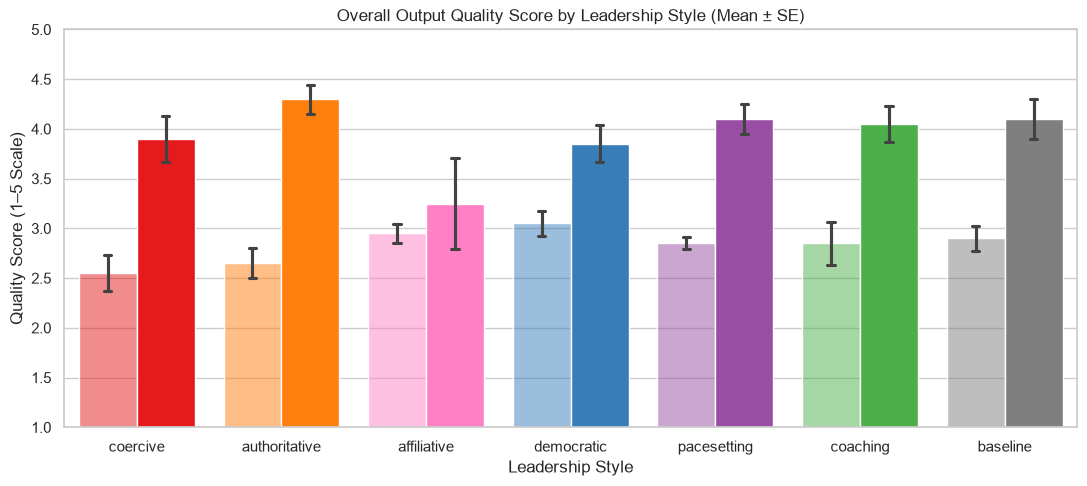

            style   task  mean       std
0        coercive   long  3.90  0.518411
1        coercive  short  2.55  0.410792
2   authoritative   long  4.30  0.325960
3   authoritative  short  2.65  0.335410
4     affiliative   long  3.25  1.030776
5     affiliative  short  2.95  0.209165
6      democratic   long  3.85  0.418330
7      democratic  short  3.05  0.273861
8     pacesetting   long  4.10  0.335410
9     pacesetting  short  2.85  0.136931
10       coaching   long  4.05  0.410792
11       coaching  short  2.85  0.487340
12       baseline   long  4.10  0.454148
13       baseline  short  2.90  0.285044


In [108]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df, x='style', y='quality_mean', hue='task', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax, legend=False, hue_order=['short', 'long'])
color_style_task_bars(ax)

ax.set_title('Overall Output Quality Score by Leadership Style (Mean ± SE)')
ax.set_ylabel('Quality Score (1–5 Scale)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(1, 5)
plt.tight_layout()
save_fig('03_quality_by_style')
plt.show()

# Print summary table
quality_summary = df.groupby(['style', 'task'])['quality_mean'].agg(['mean', 'std']).reset_index()
print(quality_summary)

### §1b — Quality Dimension Breakdown (Accuracy, Completeness, Cohesion, Quality)

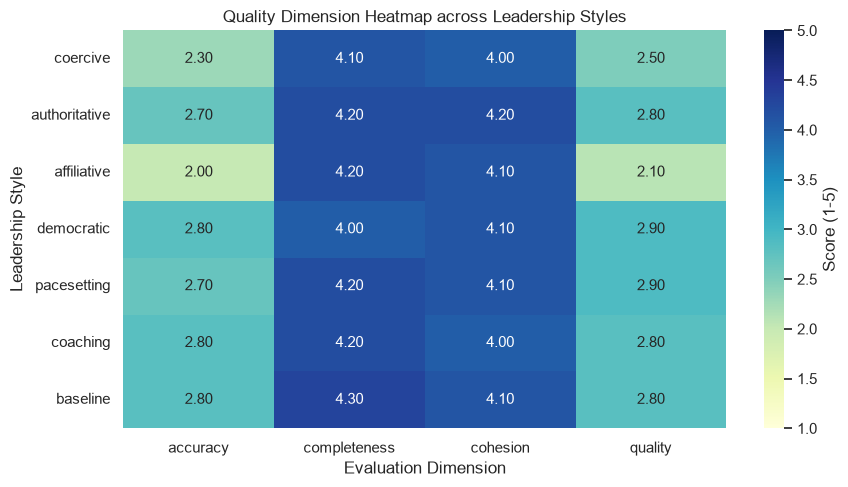

In [109]:
dim_cols = ['accuracy', 'completeness', 'cohesion', 'quality']
dim_means = df.groupby('style')[dim_cols].mean().reindex(STYLE_ORDER)

plt.figure(figsize=(9, 5))
sns.heatmap(dim_means, annot=True, cmap='YlGnBu', fmt='.2f', vmin=1, vmax=5, cbar_kws={'label': 'Score (1-5)'})
plt.title('Quality Dimension Heatmap across Leadership Styles')
plt.xlabel('Evaluation Dimension')
plt.ylabel('Leadership Style')
plt.tight_layout()
save_fig('03_quality_dimension_heatmap')
plt.show()

### §1c — Data Trap Detection Performance

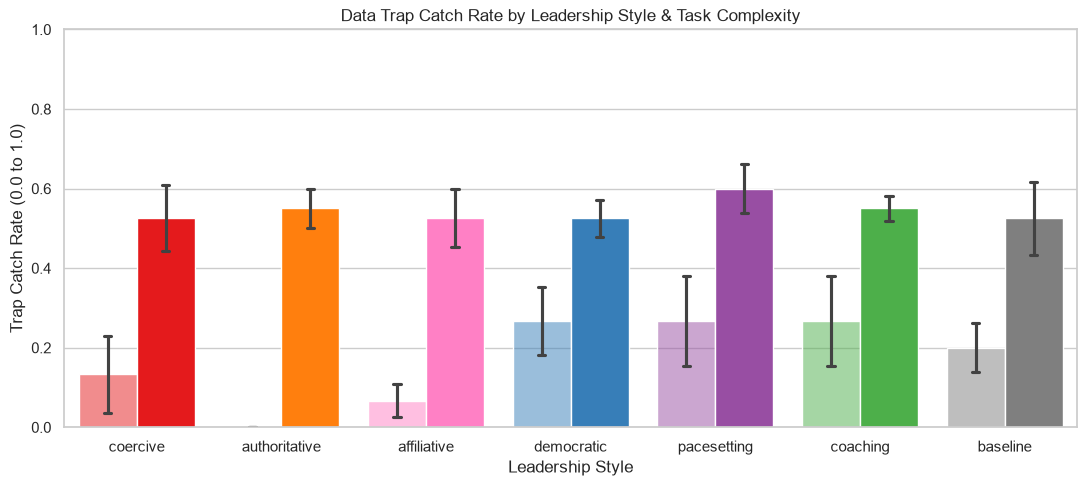

In [110]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df, x='style', y='trap_catch_rate', hue='task', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax, legend=False, hue_order=['short', 'long'])
color_style_task_bars(ax)

ax.set_title('Data Trap Catch Rate by Leadership Style & Task Complexity')
ax.set_ylabel('Trap Catch Rate (0.0 to 1.0)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(0, 1.0)
plt.tight_layout()
save_fig('03_trap_catch_rate_by_style')
plt.show()

## §2 — DV 2: Efficiency (Automatically Tracked)

Analyze computational and temporal resource consumption across conditions:
- Total Token Usage per run
- Wall-Clock Duration (total seconds per run)
- Revision Rounds

Per-agent efficiency diagnostics are located in `02_validation_check.ipynb`.


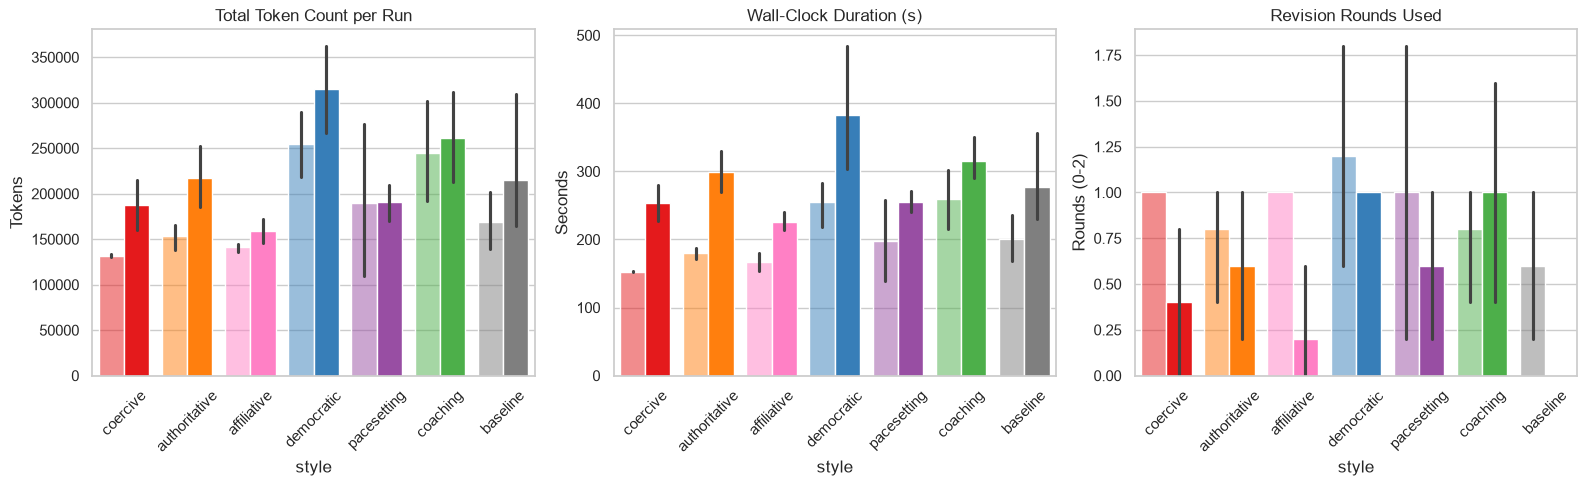

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df, x='style', y='total_tokens', hue='task', order=STYLE_ORDER, ax=axes[0], legend=False, hue_order=['short', 'long'])
color_style_task_bars(axes[0])

axes[0].set_title('Total Token Count per Run')
axes[0].set_ylabel('Tokens')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='style', y='duration_seconds', hue='task', order=STYLE_ORDER, ax=axes[1], legend=False, hue_order=['short', 'long'])
color_style_task_bars(axes[1])

axes[1].set_title('Wall-Clock Duration (s)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='style', y='revision_rounds', hue='task', order=STYLE_ORDER, ax=axes[2], legend=False, hue_order=['short', 'long'])
color_style_task_bars(axes[2])

axes[2].set_title('Revision Rounds Used')
axes[2].set_ylabel('Rounds (0-2)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('03_efficiency')
plt.show()

In [112]:
# Efficiency summary: token and duration costs by leadership style
# This cell reproduces the key numbers for the efficiency section.

print("Mean tokens and duration by style:")
eff_table = (
    df.groupby('style')[['total_tokens', 'duration_seconds']]
      .mean()
      .reindex(STYLE_ORDER)
      .round(0)
      .astype(int)
)
print(eff_table.to_string())
print()

# Extra token cost of participatory styles vs. the baseline-like styles
baseline_tokens = eff_table.loc['baseline', 'total_tokens']
for style in ['coaching', 'democratic']:
    extra = int(eff_table.loc[style, 'total_tokens'] - baseline_tokens)
    print(f"{style.capitalize()} extra tokens vs. baseline: {extra:,}")
print()

# Kruskal-Wallis by task for tokens and duration
kw_metrics = {
    'Tokens': 'total_tokens',
    'Duration (s)': 'duration_seconds',
}
print("Kruskal-Wallis by task:")
for metric_name, col in kw_metrics.items():
    for task in ['short', 'long']:
        df_task = df[df['task'] == task]
        groups = [df_task[df_task['style'] == s][col].dropna().values for s in STYLE_ORDER]
        H, p = stats.kruskal(*groups)
        n = sum(len(g) for g in groups)
        k = len(groups)
        eps2 = (H - k + 1) / (n - k) if n > k else np.nan
        p_str = f"{p:.3f}" if p >= 0.001 else "<.001"
        e_str = f"{eps2:.2f}"
        print(f"  {metric_name:15s} {task:5s}  p = {p_str},  ε² = {e_str}")
print()

# Spearman: token spend vs. quality within each task
print("Spearman: total tokens vs. output quality within task:")
for task in ['short', 'long']:
    d = df[df['task'] == task]
    rho, p = stats.spearmanr(d['total_tokens'], d['quality_mean'])
    print(f"  {task:5s}  ρ = {rho:+.2f}, p = {p:.2f}")

Mean tokens and duration by style:
               total_tokens  duration_seconds
style                                        
coercive             159757               204
authoritative        185404               240
affiliative          150222               197
democratic           284438               319
pacesetting          190312               227
coaching             252872               288
baseline             191766               239

Coaching extra tokens vs. baseline: 61,106
Democratic extra tokens vs. baseline: 92,672

Kruskal-Wallis by task:
  Tokens          short  p = 0.007,  ε² = 0.42
  Tokens          long   p = 0.008,  ε² = 0.41
  Duration (s)    short  p = 0.004,  ε² = 0.47
  Duration (s)    long   p = 0.007,  ε² = 0.41

Spearman: total tokens vs. output quality within task:
  short  ρ = +0.31, p = 0.07
  long   ρ = -0.15, p = 0.39


### §2a — Coder Resilience: Code Execution Failures and Revision Incidence

This plot tests whether the **Boss style** pressured the Coder into more broken code.

- **Grouped bars:** mean total code executions and failed executions per style, split by task.
- **Black line overlay (right y-axis):** **revision incidence** — the percentage of runs in that condition that entered Phase 6 at least once (`revision_rounds >= 1`).

> **Terminology (important):** *revision **incidence*** (used here) = share of runs with **at least one** revision round. This is **not** the same as *revision **saturation*** in `02_validation_check.ipynb` §2.1, which is the share of runs that exhausted the **maximum** of 2 rounds (5/70 = 7.1%). Incidence is high (up to 100%), saturation is low; the earlier draft used the word "saturation" for both, which was wrong.

Under Coercive or Pacesetting styles we expect higher failed-execution counts and higher revision incidence; warm styles should show fewer crashes and fewer late-cycle revisions.


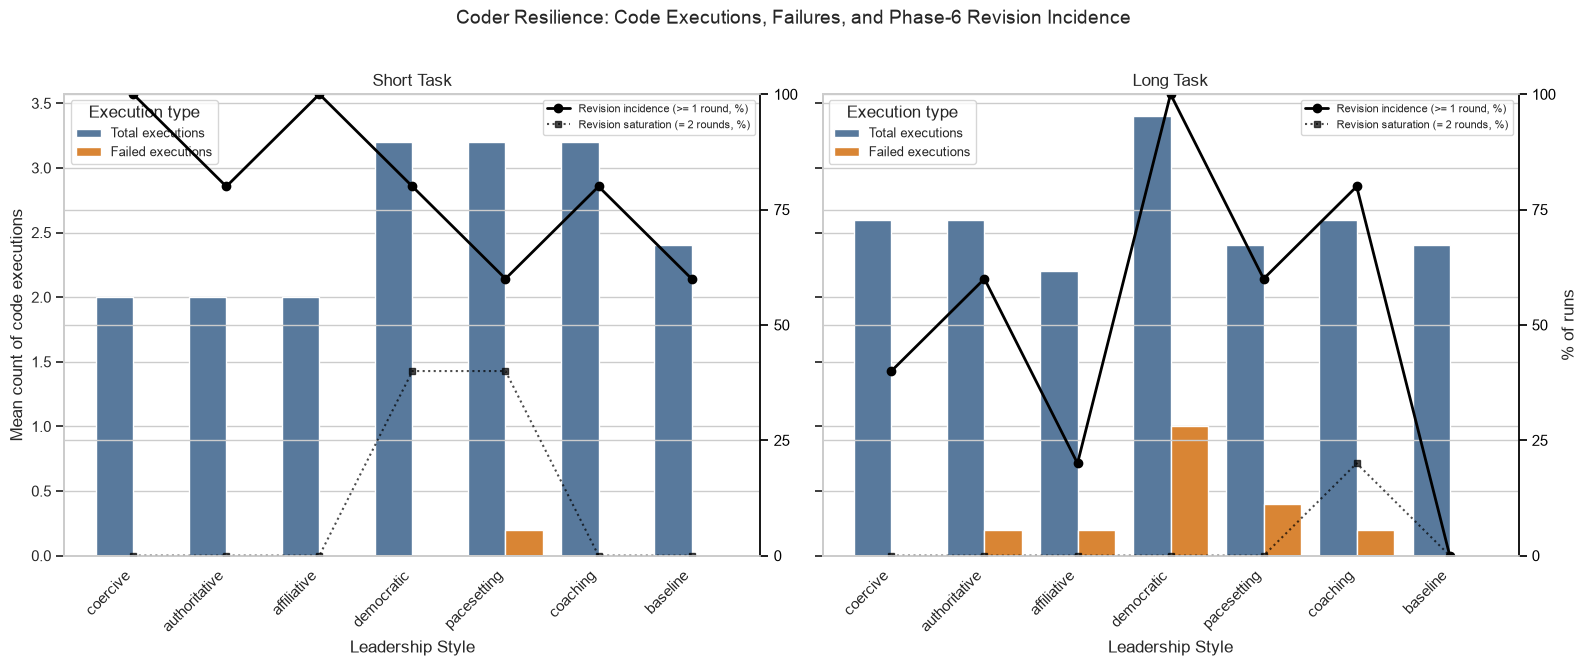

Coder resilience summary by style and task:
  revision_incidence  = % of runs with >= 1 revision round
  revision_saturation = % of runs that hit the max of 2 rounds
        style  task  total_mean  failed_mean  revision_incidence  revision_saturation
  affiliative  long         2.2          0.2                20.0                  0.0
  affiliative short         2.0          0.0               100.0                  0.0
authoritative  long         2.6          0.2                60.0                  0.0
authoritative short         2.0          0.0                80.0                  0.0
     baseline  long         2.4          0.0                 0.0                  0.0
     baseline short         2.4          0.0                60.0                  0.0
     coaching  long         2.6          0.2                80.0                 20.0
     coaching short         3.2          0.0                80.0                  0.0
     coercive  long         2.6          0.0                

In [113]:
# Load code execution logs per run to count successes and failures
res_rows = []
for d in run_dirs:
    code_file = os.path.join(d, 'code_executions.jsonl')
    if not os.path.exists(code_file):
        continue
    folder = os.path.basename(d)
    parts = folder.split('_')
    total = 0
    failed = 0
    with open(code_file, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            total += 1
            if not rec.get('success', True):
                failed += 1
    # revision rounds for this run (from df)
    run_meta = df[df['folder'] == folder]
    rev_rounds = run_meta['revision_rounds'].iloc[0] if not run_meta.empty else 0
    res_rows.append({
        'style': parts[0],
        'task': parts[1],
        'run': folder,
        'total_code_executions': total,
        'failed_executions': failed,
        'revision_rounds': rev_rounds
    })

res_df = pd.DataFrame(res_rows)

# Aggregate to style / task means.
# revision_incidence = % of runs with AT LEAST ONE revision round (>= 1).
# revision_saturation = % of runs that exhausted the maximum of 2 rounds (see nb 02 §2.1).
MAX_REVISION_ROUNDS = 2
res_agg = (res_df.groupby(['style', 'task'], observed=True)
              .agg(
                  total_mean=('total_code_executions', 'mean'),
                  failed_mean=('failed_executions', 'mean'),
                  revision_incidence=('revision_rounds', lambda x: (x >= 1).mean() * 100),
                  revision_saturation=('revision_rounds', lambda x: (x >= MAX_REVISION_ROUNDS).mean() * 100)
              )
              .reset_index())

# Long-format for the bar plot
res_long = res_agg.melt(
    id_vars=['style', 'task'],
    value_vars=['total_mean', 'failed_mean'],
    var_name='metric', value_name='count'
)
res_long['metric'] = res_long['metric'].map({
    'total_mean': 'Total executions',
    'failed_mean': 'Failed executions'
})

metric_palette = {
    'Total executions': '#4c78a8',
    'Failed executions': '#f58518'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)

tasks = ['short', 'long']
for i, (ax, task) in enumerate(zip(axes, tasks)):
    task_data = res_long[res_long['task'] == task]
    sns.barplot(
        data=task_data,
        x='style', y='count', hue='metric',
        order=STYLE_ORDER,
        hue_order=list(metric_palette.keys()),
        palette=metric_palette,
        ax=ax
    )
    # Clean x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('Leadership Style')
    ax.set_ylabel('Mean count of code executions' if i == 0 else '')
    ax.set_title(f'{task.capitalize()} Task')
    ax.legend(title='Execution type', loc='upper left', fontsize=9)

    # Overlay: revision incidence (>= 1 round) and revision saturation (= max rounds)
    cond = res_agg[res_agg['task'] == task].set_index('style').reindex(STYLE_ORDER)
    ax2 = ax.twinx()
    ax2.plot(range(len(STYLE_ORDER)), cond['revision_incidence'].values,
             color='black', marker='o', linewidth=2, markersize=6,
             label='Revision incidence (>= 1 round, %)')
    ax2.plot(range(len(STYLE_ORDER)), cond['revision_saturation'].values,
             color='black', marker='s', linestyle=':', linewidth=1.5, markersize=5,
             alpha=0.7, label=f'Revision saturation (= {MAX_REVISION_ROUNDS} rounds, %)')
    ax2.set_ylim(0, 100)
    ax2.set_yticks([0, 25, 50, 75, 100])
    ax2.tick_params(axis='y', colors='black')
    ax2.spines['right'].set_color('black')
    if i == 1:
        ax2.set_ylabel('% of runs')
    else:
        ax2.set_ylabel('')
    ax2.legend(loc='upper right', fontsize=8)

fig.suptitle('Coder Resilience: Code Executions, Failures, and Phase-6 Revision Incidence', fontsize=14, y=1.02)
fig.tight_layout()
save_fig('03_coder_resilience')
plt.show()

print('Coder resilience summary by style and task:')
print('  revision_incidence  = % of runs with >= 1 revision round')
print(f'  revision_saturation = % of runs that hit the max of {MAX_REVISION_ROUNDS} rounds')
print(res_agg.round(2).to_string(index=False))

## §3 — DV 3: Worker Satisfaction (6-Item Likert Survey)

Analyze subjective team satisfaction measured via the post-experiment standardized questionnaire (1–5 scale).


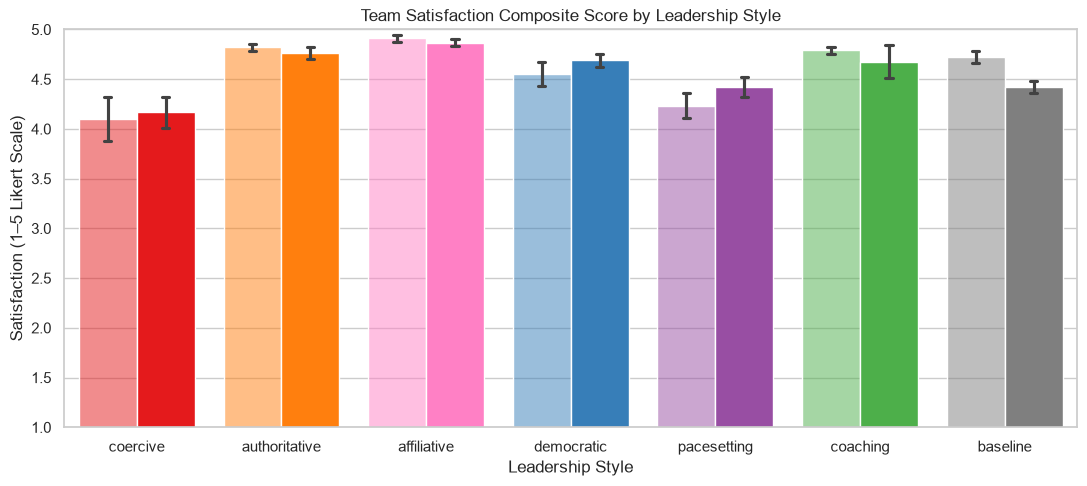

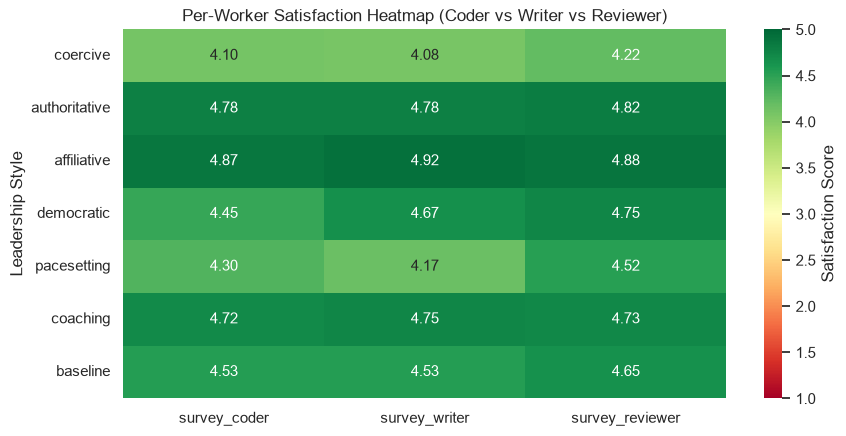

In [114]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df, x='style', y='survey_team_mean', hue='task', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax, legend=False, hue_order=['short', 'long'])
color_style_task_bars(ax)

ax.set_title('Team Satisfaction Composite Score by Leadership Style')
ax.set_ylabel('Satisfaction (1–5 Likert Scale)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(1, 5)
plt.tight_layout()
save_fig('03_satisfaction_by_style')
plt.show()

# Per worker breakdown
worker_cols = ['survey_coder', 'survey_writer', 'survey_reviewer']
df_worker_sat = df.groupby('style')[worker_cols].mean().reindex(STYLE_ORDER)

plt.figure(figsize=(9, 4.5))
sns.heatmap(df_worker_sat, annot=True, cmap='RdYlGn', fmt='.2f', vmin=1, vmax=5, cbar_kws={'label': 'Satisfaction Score'})
plt.title('Per-Worker Satisfaction Heatmap (Coder vs Writer vs Reviewer)')
plt.ylabel('Leadership Style')
plt.tight_layout()
save_fig('03_satisfaction_worker_heatmap')
plt.show()

### §3a — Worker Experience & Survey Breakdown (Q1–Q6)

This grouped horizontal bar chart shows the mean adjusted score for every survey item across the seven leadership styles. Item 4 is reverse-coded, so a high score means workers perceived **less** micromanagement / more autonomy.

Use this view to spot:
- **Ceiling effects** on items Q1, Q2, Q3, Q5 and Q6.
- **Q4 floor effect** for Coercive / Pacesetting, where perceived micromanagement drags the score down relative to Coaching / Affiliative.


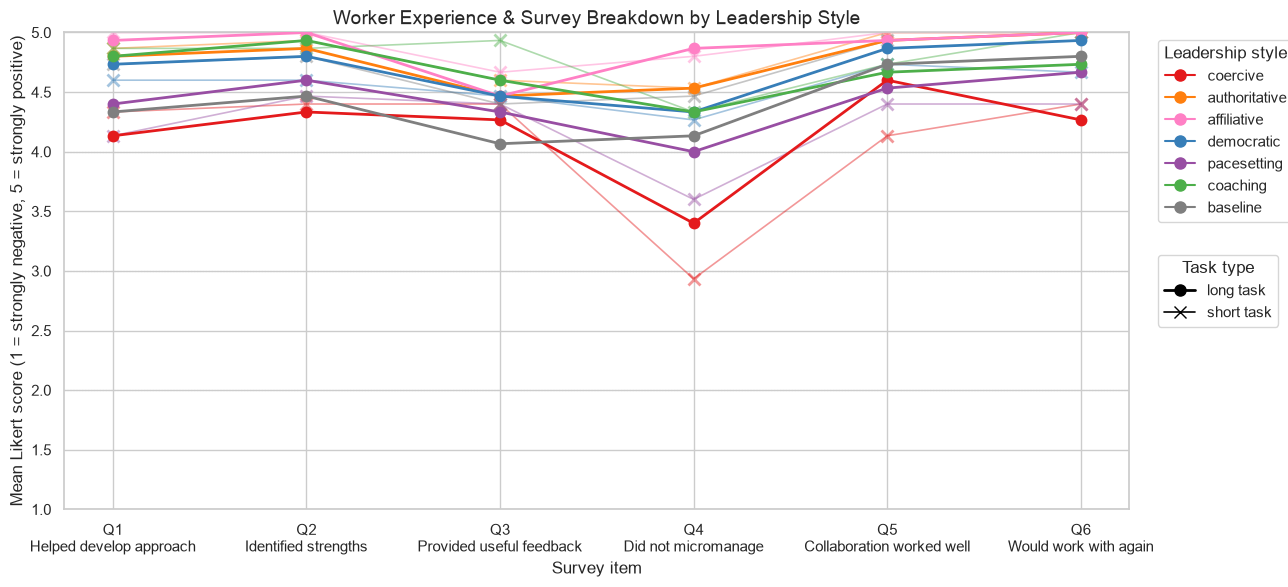

Survey items:
  Q1 — Helped develop approach
  Q2 — Identified strengths
  Q3 — Provided useful feedback
  Q4 — Did not micromanage
  Q5 — Collaboration worked well
  Q6 — Would work with again


In [115]:
SURVEY_ITEM_LABELS = {
    'Q1': 'Q1 — Helped develop approach',
    'Q2': 'Q2 — Identified strengths',
    'Q3': 'Q3 — Provided useful feedback',
    'Q4': 'Q4 — Did not micromanage',
    'Q5': 'Q5 — Collaboration worked well',
    'Q6': 'Q6 — Would work with again',
}

# Load individual item scores (adjusted) from survey_results.json
item_rows = []
for d in run_dirs:
    surv_path = os.path.join(d, 'survey_results.json')
    if not os.path.exists(surv_path):
        continue
    with open(surv_path, 'r', encoding='utf-8') as f:
        survey = json.load(f)
    folder = os.path.basename(d)
    parts = folder.split('_')
    for worker, wdata in survey.get('workers', {}).items():
        adj = wdata.get('adjusted_scores')
        if not adj:
            continue
        for q, score in adj.items():
            item_rows.append({
                'run': folder,
                'style': parts[0],
                'task': parts[1],
                'worker': worker,
                'item': q.upper(),
                'score': float(score)
            })

df_items = pd.DataFrame(item_rows)
df_items['style'] = pd.Categorical(df_items['style'], categories=STYLE_ORDER, ordered=True)

# Mean score per style, task and item (aggregated across runs and worker roles)
df_item_mean = (df_items.groupby(['style', 'task', 'item'], observed=True)['score']
                         .mean()
                         .reset_index())

item_order = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']

fig, ax = plt.subplots(figsize=(13, 6))

# One colour per leadership style; long = solid o, short = lighter x
from matplotlib.lines import Line2D
style_handles = []
for style in STYLE_ORDER:
    color = STYLE_COLORS[style]
    for task, marker, alpha, width in [('short', 'x', 0.45, 1.2), ('long', 'o', 1.0, 2.0)]:
        task_data = df_item_mean[
            (df_item_mean['style'] == style) & (df_item_mean['task'] == task)
        ].set_index('item').reindex(item_order)
        ax.plot(
            item_order, task_data['score'],
            color=color,
            marker=marker,
            markersize=8 if marker == 'x' else 7,
            markeredgewidth=2 if marker == 'x' else 1.5,
            linewidth=width,
            alpha=alpha,
            zorder=3 if alpha == 1.0 else 2
        )
    style_handles.append(Line2D([0], [0], color=color, marker='o', markersize=8, label=style))

# Two-part legend: leadership styles, then task markers
style_legend = ax.legend(handles=style_handles, title='Leadership style', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.add_artist(style_legend)

task_handles = [
    Line2D([0], [0], color='black', marker='o', markersize=8, label='long task', linewidth=2),
    Line2D([0], [0], color='black', marker='x', markersize=8, label='short task', linewidth=1.2)
]
ax.legend(handles=task_handles, title='Task type', bbox_to_anchor=(1.02, 0.55), loc='upper left')

# Use the full question descriptions on the x-axis
ax.set_xticks(item_order)
ax.set_xticklabels(
    [SURVEY_ITEM_LABELS[q].replace(' — ', '\n') for q in item_order],
    rotation=0,
    ha='center'
)

ax.set_ylim(1, 5)
ax.set_ylabel('Mean Likert score (1 = strongly negative, 5 = strongly positive)')
ax.set_xlabel('Survey item')
ax.set_title('Worker Experience & Survey Breakdown by Leadership Style', fontsize=14)

# Highlight the score midpoints to make floor/ceiling easier to read
for y in [2, 3, 4]:
    ax.axhline(y, color='lightgray', linestyle=':', linewidth=0.8, zorder=0)

plt.tight_layout()
save_fig('03_survey_items')
plt.show()

# Print the item text for reference
print('Survey items:')
for q, label in SURVEY_ITEM_LABELS.items():
    print(f'  {label}')

### §3b — Within-Run Worker Variance in Satisfaction

Boxplot / strip plot of the composite satisfaction score for each **agent role** (Coder, Writer, Reviewer) within every leadership style.

This helps spot whether certain styles create role-specific dissatisfaction — for example, whether the Coder under **Coercive** or **Pacesetting** scores far below the Writer or Reviewer, or whether warm styles produce uniform, high scores across all three roles.


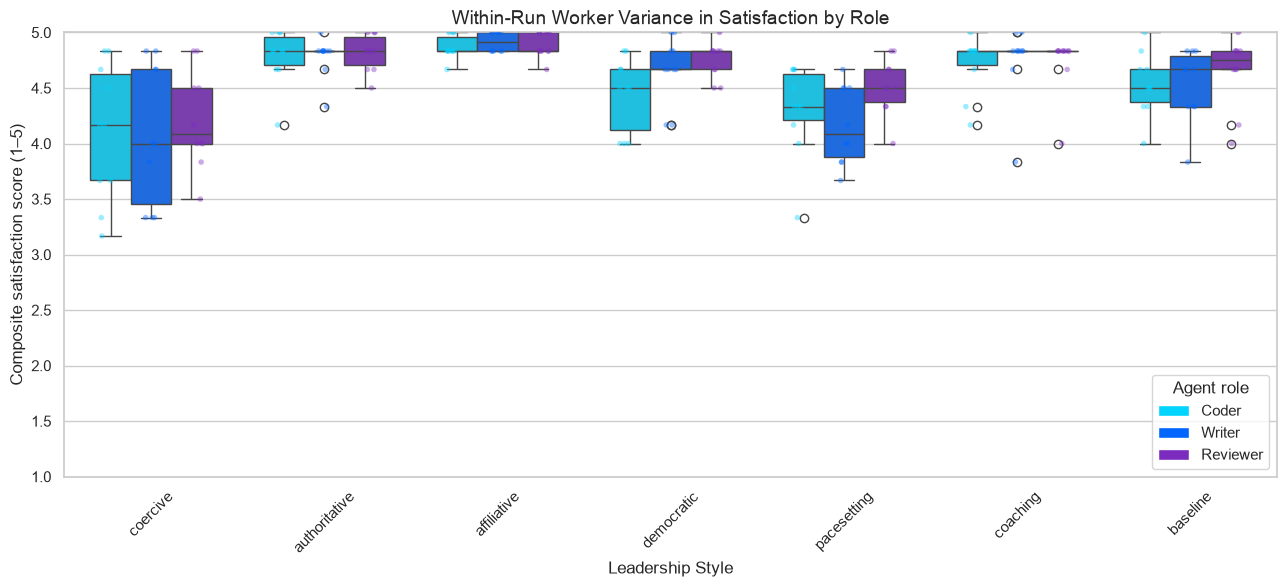

Mean satisfaction by style and role:
role           Coder  Reviewer  Writer
style                                 
coercive        4.10      4.22    4.08
authoritative   4.78      4.82    4.78
affiliative     4.87      4.88    4.92
democratic      4.45      4.75    4.67
pacesetting     4.30      4.52    4.17
coaching        4.72      4.73    4.75
baseline        4.53      4.65    4.53


In [116]:
# Melt the per-role satisfaction columns into long format
df_roles = (df[['style', 'task', 'survey_coder', 'survey_writer', 'survey_reviewer']]
              .melt(id_vars=['style', 'task'],
                    value_vars=['survey_coder', 'survey_writer', 'survey_reviewer'],
                    var_name='role', value_name='satisfaction'))
df_roles['role'] = df_roles['role'].map({
    'survey_coder': 'Coder',
    'survey_writer': 'Writer',
    'survey_reviewer': 'Reviewer'
})
df_roles = df_roles.dropna(subset=['satisfaction'])

# Role color palette (not the style palette)
role_palette = {
    'Coder': '#00D4FF',
    'Writer': '#0066FF',
    'Reviewer': '#7B2CBF'
}

fig, ax = plt.subplots(figsize=(13, 6))

# Boxplots by style, colored by role
sns.boxplot(
    data=df_roles,
    x='style', y='satisfaction', hue='role',
    order=STYLE_ORDER,
    palette=role_palette,
    width=0.7,
    ax=ax
)

# Overlay individual run points
sns.stripplot(
    data=df_roles,
    x='style', y='satisfaction', hue='role',
    order=STYLE_ORDER,
    palette=role_palette,
    dodge=True,
    size=4,
    alpha=0.4,
    linewidth=0,
    ax=ax,
    legend=False
)

ax.set_ylim(1, 5)
ax.set_xlabel('Leadership Style')
ax.set_ylabel('Composite satisfaction score (1–5)')
ax.set_title('Within-Run Worker Variance in Satisfaction by Role', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# Clean legend: show one patch per role
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=role_palette[r], edgecolor='white', label=r) for r in role_palette]
ax.legend(handles=legend_elements, title='Agent role', loc='lower right')

plt.tight_layout()
save_fig('03_satisfaction_within_run_variance')
plt.show()

# Quick numeric check: role means by style
print('Mean satisfaction by style and role:')
print(df_roles.groupby(['style', 'role'])['satisfaction'].mean().unstack().round(2).reindex(STYLE_ORDER).to_string())

### §3c — Role-Specific Dissatisfaction Slope

Slope chart of the **per-role composite satisfaction** (Coder, Writer, Reviewer) for each leadership style.

- **Faded dots:** individual run scores.
- **Colored lines:** mean satisfaction per style, with 90% confidence intervals.

This reveals whether all workers suffer equally under a demanding style, or whether the Coder — who bears debugging pressure — is systematically more dissatisfied than the Writer or Reviewer.


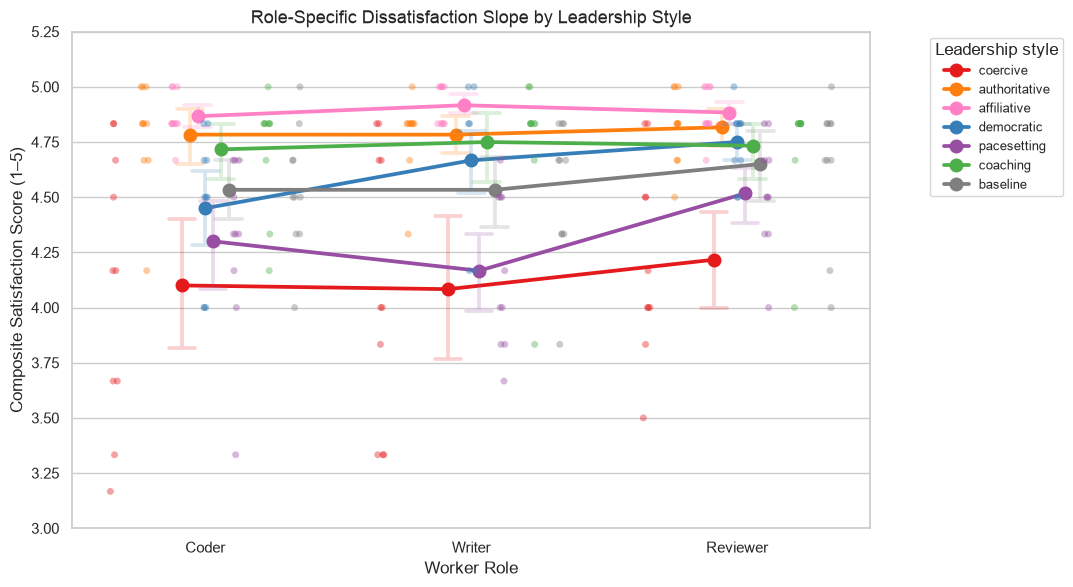

Mean satisfaction by style and role:
role           Coder  Reviewer  Writer
style                                 
coercive        4.10      4.22    4.08
authoritative   4.78      4.82    4.78
affiliative     4.87      4.88    4.92
democratic      4.45      4.75    4.67
pacesetting     4.30      4.52    4.17
coaching        4.72      4.73    4.75
baseline        4.53      4.65    4.53


In [117]:
# Melt per-role satisfaction columns into long format
df_roles = (df[['style', 'survey_coder', 'survey_writer', 'survey_reviewer']]
              .melt(id_vars=['style'],
                    value_vars=['survey_coder', 'survey_writer', 'survey_reviewer'],
                    var_name='role', value_name='satisfaction'))
df_roles['role'] = df_roles['role'].map({
    'survey_coder': 'Coder',
    'survey_writer': 'Writer',
    'survey_reviewer': 'Reviewer'
})
df_roles = df_roles.dropna(subset=['satisfaction'])

fig, ax = plt.subplots(figsize=(11, 6))

# Individual run points in the background
sns.stripplot(
    data=df_roles,
    x='role', y='satisfaction', hue='style',
    order=['Coder', 'Writer', 'Reviewer'],
    hue_order=STYLE_ORDER,
    palette=STYLE_COLORS,
    dodge=True,
    jitter=True,
    size=5,
    alpha=0.4,
    ax=ax,
    legend=False
)

# Mean slope per style with 90% CI
sns.pointplot(
    data=df_roles,
    x='role', y='satisfaction', hue='style',
    order=['Coder', 'Writer', 'Reviewer'],
    hue_order=STYLE_ORDER,
    palette=STYLE_COLORS,
    dodge=True,
    markersize=8,
    linestyles='-',
    errorbar=('ci', 90),
    capsize=0.1,
    err_kws={'alpha': 0.2},
    ax=ax
)

ax.set_ylim(3.0, 5.25)
ax.set_xlabel('Worker Role')
ax.set_ylabel('Composite Satisfaction Score (1–5)')
ax.set_title('Role-Specific Dissatisfaction Slope by Leadership Style', fontsize=13)
ax.legend(title='Leadership style', loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=9)
plt.tight_layout()
save_fig('03_dissatisfaction_slope_by_role')
plt.show()

# Quick numerical check: role means by style
print('Mean satisfaction by style and role:')
print(df_roles.groupby(['style', 'role'])['satisfaction'].mean().unstack().reindex(STYLE_ORDER).round(2).to_string())

## §4 — Cross-DV Relationships & Correlations

Examine how Output Quality, Efficiency (Tokens/Duration) and Worker Satisfaction relate to each other.

> **Pooled correlations across both tasks are confounded by task type and must not be interpreted.** The long task systematically consumes more tokens *and* receives higher judge scores than the short task (mean quality 3.94 vs 2.83, p ≈ 1e-9). Any pooled quality–cost correlation therefore mostly reflects "long tasks are bigger and score higher", not "spending more tokens buys quality" — a textbook Simpson's-paradox setup. Every correlation below is therefore reported **three times**: pooled (for reference only), and separately **within the short task** and **within the long task**. Only the within-task values are interpretable.


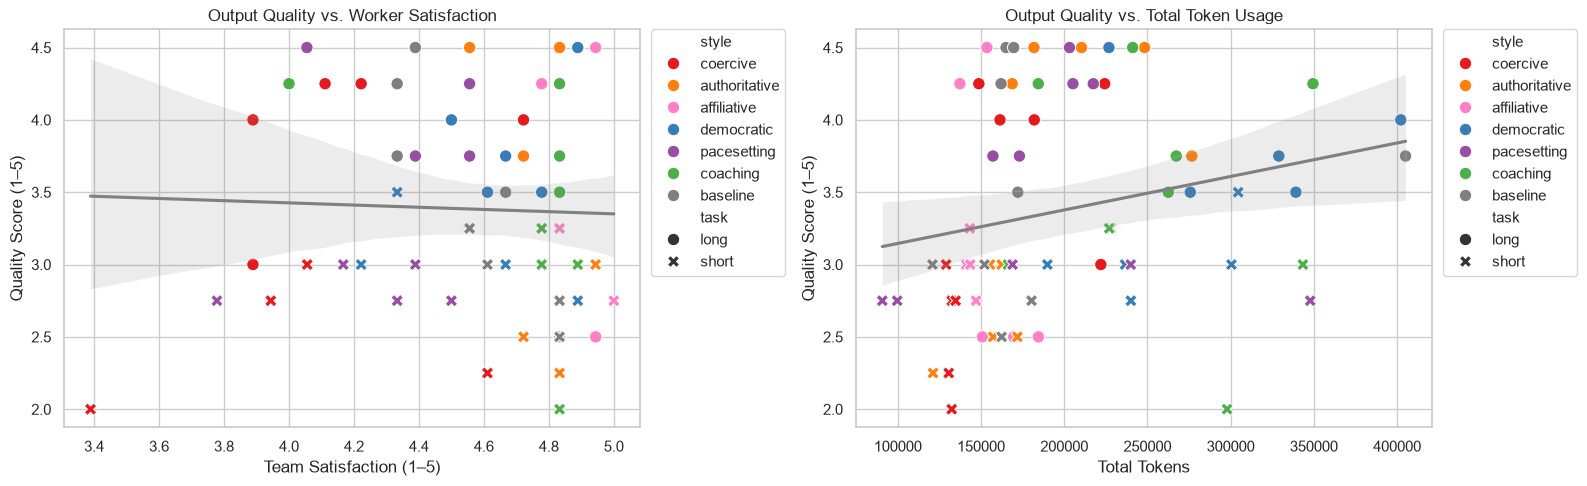

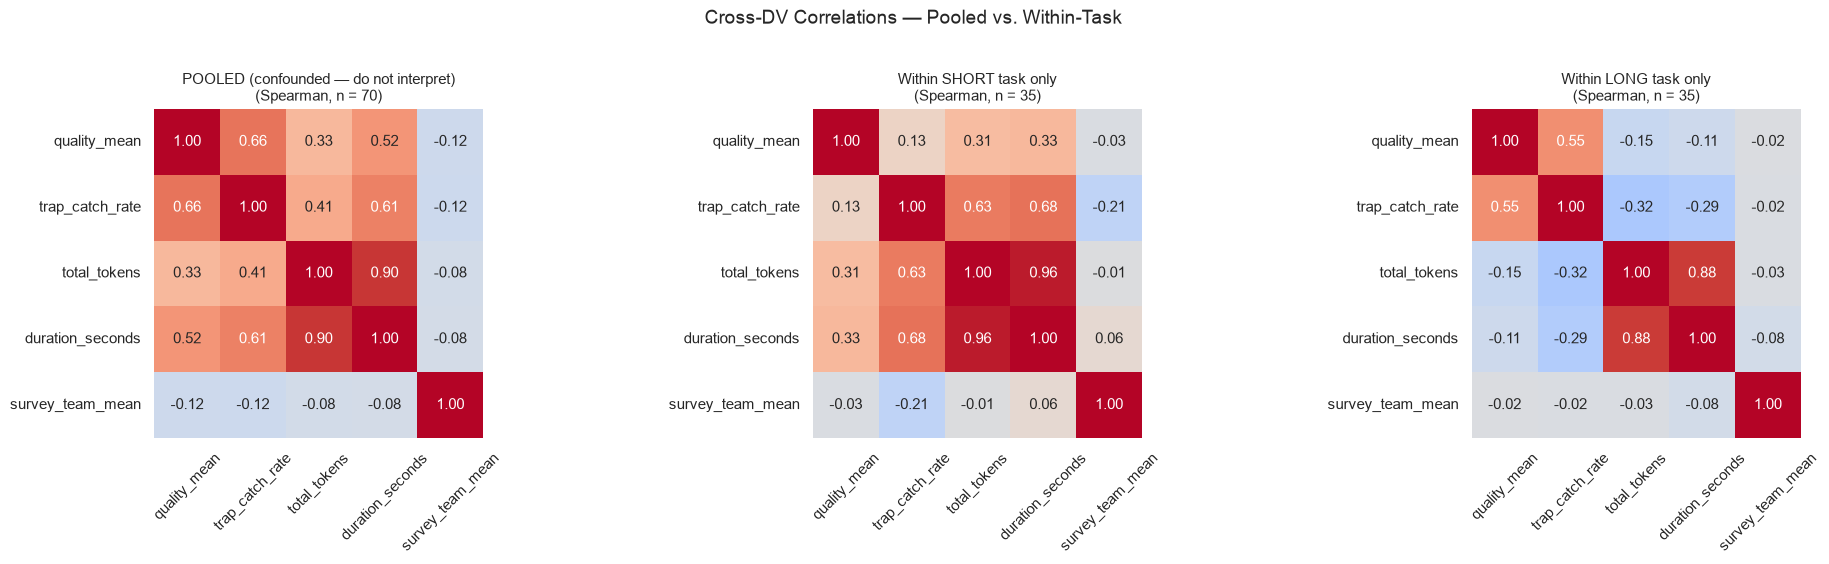

   CROSS-DV CORRELATIONS — POOLED vs. WITHIN TASK
   Only the within-task rows are interpretable; the pooled rows mix two task types.
                    Relationship               Scope  n  Spearman rho  p-value Significant
        Quality  ~  Satisfaction pooled (confounded) 70        -0.117   0.3346          No
        Quality  ~  Satisfaction          short task 35        -0.030   0.8655          No
        Quality  ~  Satisfaction           long task 35        -0.018   0.9171          No
        Quality  ~  Total tokens pooled (confounded) 70         0.334   0.0047         Yes
        Quality  ~  Total tokens          short task 35         0.309   0.0712          No
        Quality  ~  Total tokens           long task 35        -0.150   0.3883          No
            Quality  ~  Duration pooled (confounded) 70         0.519   0.0000         Yes
            Quality  ~  Duration          short task 35         0.332   0.0515          No
            Quality  ~  Duration           long

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Quality vs Satisfaction
sns.scatterplot(data=df, x='survey_team_mean', y='quality_mean', hue='style', style='task', s=80, palette=STYLE_COLORS, ax=axes[0])
sns.regplot(data=df, x='survey_team_mean', y='quality_mean', scatter=False, ax=axes[0], color='gray')
axes[0].set_title('Output Quality vs. Worker Satisfaction')
axes[0].set_xlabel('Team Satisfaction (1–5)')
axes[0].set_ylabel('Quality Score (1–5)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, title='')

# Quality vs Tokens
sns.scatterplot(data=df, x='total_tokens', y='quality_mean', hue='style', style='task', s=80, palette=STYLE_COLORS, ax=axes[1])
sns.regplot(data=df, x='total_tokens', y='quality_mean', scatter=False, ax=axes[1], color='gray')
axes[1].set_title('Output Quality vs. Total Token Usage')
axes[1].set_xlabel('Total Tokens')
axes[1].set_ylabel('Quality Score (1–5)')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, title='')

plt.tight_layout()
save_fig('03_quality_vs_satisfaction_and_tokens')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Correlation matrices: pooled (confounded by task) vs. within each task
# ─────────────────────────────────────────────────────────────────────────────
corr_cols = ['quality_mean', 'trap_catch_rate', 'total_tokens', 'duration_seconds', 'survey_team_mean']

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
panels = [
    ('POOLED (confounded — do not interpret)', df, 'coolwarm'),
    ('Within SHORT task only', df[df['task'] == 'short'], 'coolwarm'),
    ('Within LONG task only', df[df['task'] == 'long'], 'coolwarm'),
]
for ax, (title, data, cmap) in zip(axes, panels):
    cm = data[corr_cols].corr(method='spearman')
    sns.heatmap(cm, annot=True, cmap=cmap, fmt='.2f', vmin=-1, vmax=1, ax=ax,
                cbar=False, square=True)
    ax.set_title(f'{title}\n(Spearman, n = {len(data)})', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Cross-DV Correlations — Pooled vs. Within-Task', fontsize=14, y=1.02)
fig.tight_layout()
save_fig('03_correlations_pooled_vs_within_task')
plt.show()

# ── Explicit significance test of the key pairs, pooled vs. within task ─────
key_pairs = [
    ('quality_mean', 'survey_team_mean', 'Quality  ~  Satisfaction'),
    ('quality_mean', 'total_tokens', 'Quality  ~  Total tokens'),
    ('quality_mean', 'duration_seconds', 'Quality  ~  Duration'),
    ('trap_catch_rate', 'total_tokens', 'Trap catch rate  ~  Total tokens'),
    ('survey_team_mean', 'total_tokens', 'Satisfaction  ~  Total tokens'),
]

rows = []
for a, b, label in key_pairs:
    for scope, data in [('pooled (confounded)', df),
                        ('short task', df[df['task'] == 'short']),
                        ('long task', df[df['task'] == 'long'])]:
        rho, p = stats.spearmanr(data[a], data[b])
        rows.append({
            'Relationship': label,
            'Scope': scope,
            'n': len(data),
            'Spearman rho': round(rho, 3),
            'p-value': round(p, 4),
            'Significant': 'Yes' if p < 0.05 else 'No'
        })

df_corr_bytask = pd.DataFrame(rows)
print('=' * 92)
print('   CROSS-DV CORRELATIONS — POOLED vs. WITHIN TASK')
print('   Only the within-task rows are interpretable; the pooled rows mix two task types.')
print('=' * 92)
print(df_corr_bytask.to_string(index=False))

# ── Headline check: does the pooled quality~tokens correlation survive? ──────
rho_pool, p_pool = stats.spearmanr(df['quality_mean'], df['total_tokens'])
rho_s, p_s = stats.spearmanr(df[df.task == 'short']['quality_mean'], df[df.task == 'short']['total_tokens'])
rho_l, p_l = stats.spearmanr(df[df.task == 'long']['quality_mean'], df[df.task == 'long']['total_tokens'])

print('\n' + '-' * 92)
print('SIMPSON CHECK — Quality vs. Token cost:')
print(f'  pooled     : rho = {rho_pool:+.3f} (p = {p_pool:.4f})  <- driven by task type, NOT by spending')
print(f'  short only : rho = {rho_s:+.3f} (p = {p_s:.4f})')
print(f'  long only  : rho = {rho_l:+.3f} (p = {p_l:.4f})')
if p_s >= 0.05 and p_l >= 0.05:
    print('  -> The pooled association DISAPPEARS within each task. Spending more tokens')
    print('     does not buy higher quality; the pooled correlation was a task artefact.')
else:
    print('  -> At least one within-task association survives; report the within-task values.')
print('-' * 92)

### §4a — Headline: Quality and Satisfaction are Decoupled (No Trade-off)

This plot addresses the central research question: do leadership styles that deliver high output quality come at the cost of worker satisfaction?

**The answer in this experiment is no — because there is no relationship at all.** Satisfaction varies strongly and significantly across styles (§3, §5), while output quality does not vary detectably (§5). Run-level Spearman correlation between the two is ρ ≈ −0.12 (p ≈ .33), i.e. indistinguishable from zero. The two dependent variables are therefore **decoupled**, not traded off against each other. An earlier version of this section was titled "Performance–Satisfaction–Efficiency Trade-off", which the data does not support; the label has been corrected.

Each point is one leadership style, plotted at the mean satisfaction and mean control-agent quality across all 10 runs (5 short + 5 long). Horizontal and vertical error bars show ±1 SD across those runs. Bubble size is scaled by mean total token consumption, so the *cost* dimension remains visible: it is cost, not quality, that moves with the more discursive styles.

> **How to read it:** the points spread out horizontally (satisfaction differs) but form a flat, noisy band vertically (quality does not). No Pareto frontier is drawn — with a between-style quality spread of ~0.4 points against within-style SDs of 0.7–0.9, "non-dominated" styles cannot be distinguished from noise.


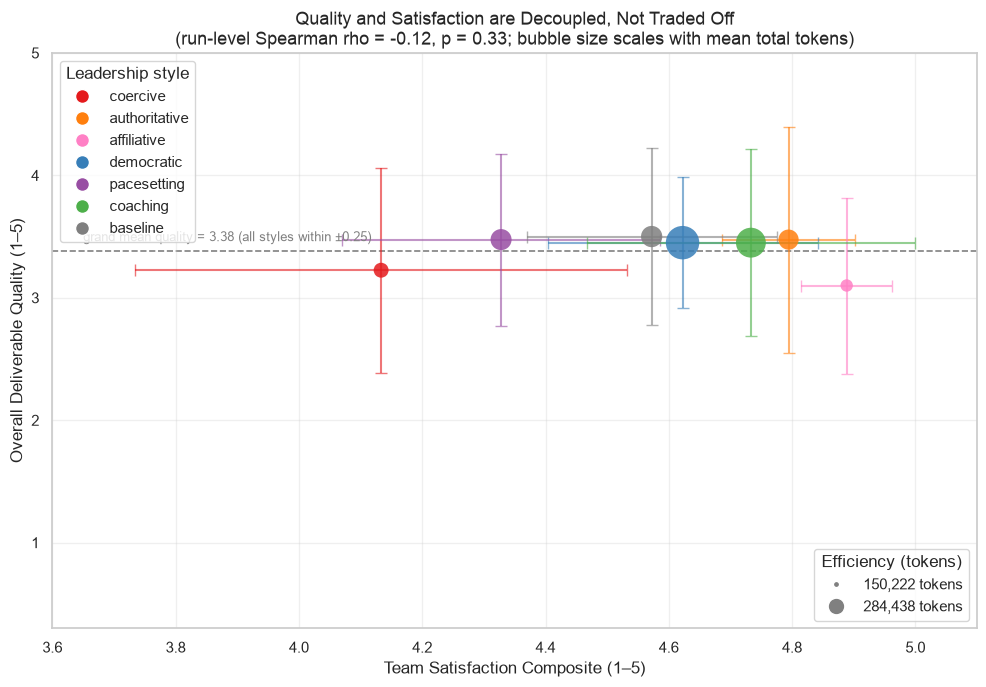

Mean satisfaction, quality and token usage per leadership style:
               satisfaction_mean  satisfaction_std  quality_mean  quality_std  tokens_mean  duration_mean
style                                                                                                    
coercive                   4.133             0.399         3.225        0.837     159756.7        203.511
authoritative              4.794             0.108         3.475        0.924     185403.9        239.652
affiliative                4.889             0.074         3.100        0.719     150222.3        196.669
democratic                 4.622             0.219         3.450        0.537     284438.0        318.839
pacesetting                4.328             0.257         3.475        0.702     190312.0        226.904
coaching                   4.733             0.266         3.450        0.762     252871.9        287.533
baseline                   4.572             0.203         3.500        0.726     19176

In [119]:
# Aggregate to style-level means ± SD
trade = (df.groupby('style', observed=False)
          .agg(
              satisfaction_mean=('survey_team_mean', 'mean'),
              satisfaction_std=('survey_team_mean', 'std'),
              quality_mean=('quality_mean', 'mean'),
              quality_std=('quality_mean', 'std'),
              tokens_mean=('total_tokens', 'mean'),
              duration_mean=('duration_seconds', 'mean')
          )
          .reindex(STYLE_ORDER))

# Bubble size scaled by mean token usage
min_tok, max_tok = trade['tokens_mean'].min(), trade['tokens_mean'].max()
bubble_size = 80 + 500 * ((trade['tokens_mean'] - min_tok) / (max_tok - min_tok))
colors = [STYLE_COLORS[s] for s in trade.index]

fig, ax = plt.subplots(figsize=(10, 7))

# Error bars first, so they sit behind the bubbles.
# NOTE: no Pareto frontier is drawn - see the markdown cell above.
for x, y, sx, sy, c in zip(
    trade['satisfaction_mean'], trade['quality_mean'],
    trade['satisfaction_std'], trade['quality_std'], colors
):
    ax.errorbar(x, y, xerr=sx, yerr=sy,
                fmt='none', ecolor=c, alpha=0.6, capsize=4, zorder=1)

ax.scatter(
    trade['satisfaction_mean'], trade['quality_mean'],
    s=bubble_size, c=colors, alpha=0.85, edgecolors='none', zorder=2
)

# Horizontal reference line at the grand mean quality: makes the flatness explicit
grand_quality = df['quality_mean'].mean()
ax.axhline(grand_quality, color='gray', linestyle='--', linewidth=1.2, zorder=0)
ax.text(3.65, grand_quality + 0.08,
        f'grand mean quality = {grand_quality:.2f} (all styles within ±0.25)',
        fontsize=9, color='gray')

rho_run, p_run = stats.spearmanr(df['survey_team_mean'], df['quality_mean'])

ax.set_xlabel('Team Satisfaction Composite (1–5)', fontsize=12)
ax.set_ylabel('Overall Deliverable Quality (1–5)', fontsize=12)
ax.set_title('Quality and Satisfaction are Decoupled, Not Traded Off\n'
             f'(run-level Spearman rho = {rho_run:.2f}, p = {p_run:.2f}; '
             'bubble size scales with mean total tokens)', fontsize=13)
ax.set_xlim(3.6, 5.1)
ax.set_ylim(0.3, 5.0)
ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D

# Legend for leadership style colors
style_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=STYLE_COLORS[s], markersize=10, label=s)
    for s in STYLE_ORDER
]
leg1 = ax.legend(handles=style_handles, title='Leadership style',
                 loc='upper left', frameon=True)
ax.add_artist(leg1)

# Legend for bubble size
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(s) / 2, label=lab)
    for s, lab in zip([bubble_size.min(), bubble_size.max()],
                      [f'{int(min_tok):,} tokens', f'{int(max_tok):,} tokens'])
]
ax.legend(handles=size_handles, title='Efficiency (tokens)', loc='lower right')

plt.tight_layout()
save_fig('03_decoupling')
plt.show()

print('Mean satisfaction, quality and token usage per leadership style:')
print(trade.round(3).to_string())
print(f'\nRun-level Spearman(satisfaction, quality) = {rho_run:.3f}, p = {p_run:.3f}')
print(f'Between-style quality spread: {trade["quality_mean"].max() - trade["quality_mean"].min():.2f} points')
print(f'Mean within-style quality SD:  {trade["quality_std"].mean():.2f} points')

-> The spread between styles is smaller than the scatter within a single style, so quality differences between styles are not interpretable. Satisfaction and token cost do differ; quality does not. It is a decoupling, not a trade-off. 

### §4b — Descriptive Variants: Quality Subscores against Satisfaction

The same descriptive map as §4a, shown for each quality subscore so it is visible that the decoupling is not an artefact of the composite score: no subscore (Accuracy, Completeness, Cohesion) or trap catch rate lines up with satisfaction either. Bubble size is scaled by either total token usage or wall-clock duration, as stated in each subplot title.

> **Descriptive only.** Error bars are ±1 SD across the 10 runs per style. In every panel the error bars overlap heavily, and none of the quality metrics differ significantly across styles (§5). Pareto frontiers have deliberately been removed from these panels: connecting "non-dominated" styles implies a precision that a 0.4-point spread with 0.7–0.9-point standard deviations does not support.


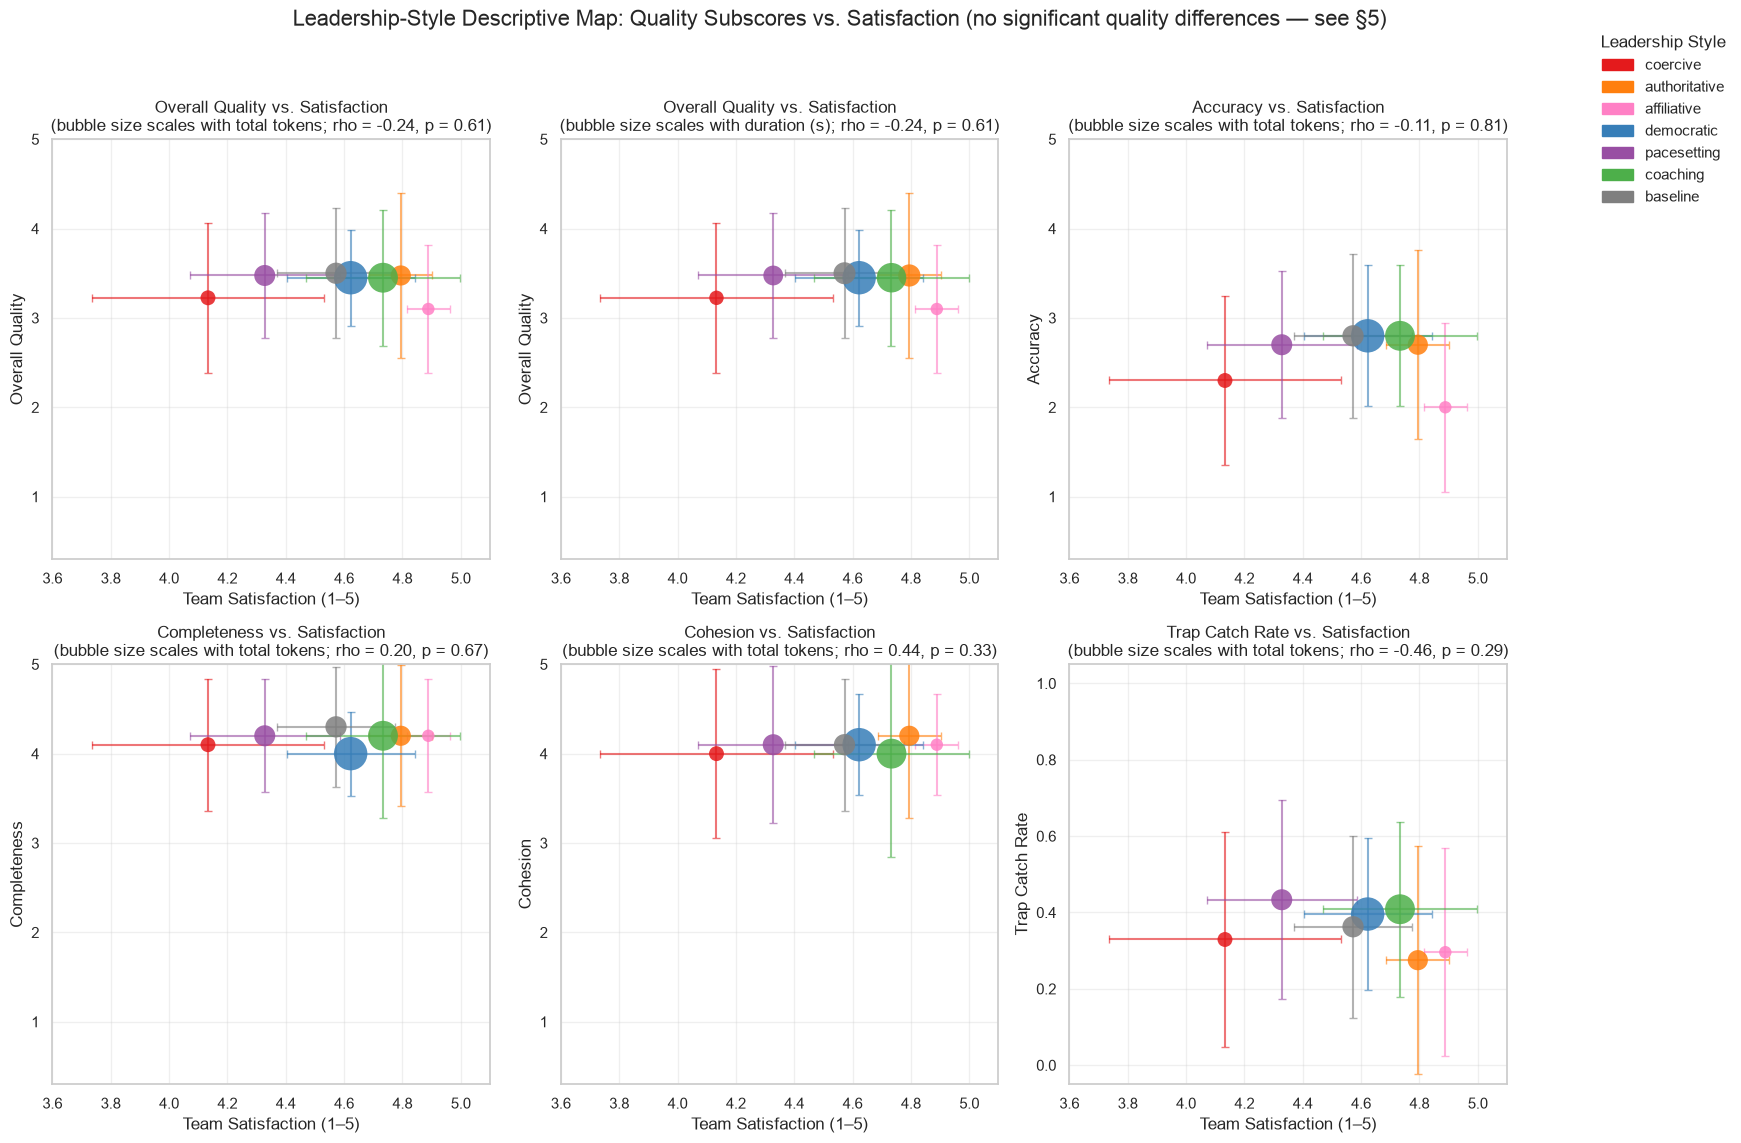

Style-level means for the six descriptive plots:
               satisfaction_mean  quality_mean  accuracy_mean  completeness_mean  cohesion_mean  trap_mean  tokens_mean  duration_mean
style                                                                                                                                 
coercive                   4.133         3.225            2.3                4.1            4.0      0.329     159756.7        203.511
authoritative              4.794         3.475            2.7                4.2            4.2      0.275     185403.9        239.652
affiliative                4.889         3.100            2.0                4.2            4.1      0.296     150222.3        196.669
democratic                 4.622         3.450            2.8                4.0            4.1      0.396     284438.0        318.839
pacesetting                4.328         3.475            2.7                4.2            4.1      0.433     190312.0        226.904
coachi

In [120]:
import matplotlib.patches as mpatches

# Style-level means ± SD for all relevant metrics
agg = (df.groupby('style', observed=False)
       .agg(
           satisfaction_mean=('survey_team_mean', 'mean'),
           satisfaction_std=('survey_team_mean', 'std'),
           quality_mean=('quality_mean', 'mean'),
           quality_std=('quality_mean', 'std'),
           accuracy_mean=('accuracy', 'mean'),
           accuracy_std=('accuracy', 'std'),
           completeness_mean=('completeness', 'mean'),
           completeness_std=('completeness', 'std'),
           cohesion_mean=('cohesion', 'mean'),
           cohesion_std=('cohesion', 'std'),
           trap_mean=('trap_catch_rate', 'mean'),
           trap_std=('trap_catch_rate', 'std'),
           tokens_mean=('total_tokens', 'mean'),
           duration_mean=('duration_seconds', 'mean')
       )
       .reindex(STYLE_ORDER))

color_list = [STYLE_COLORS[s] for s in agg.index]
min_tok, max_tok = agg['tokens_mean'].min(), agg['tokens_mean'].max()
min_dur, max_dur = agg['duration_mean'].min(), agg['duration_mean'].max()

# Plot specifications: (y mean, y std, y label, y-lim, size metric col, size label)
plot_specs = [
    ('quality_mean', 'quality_std', 'Overall Quality', (0.3, 5.0), 'tokens_mean', 'total tokens'),
    ('quality_mean', 'quality_std', 'Overall Quality', (0.3, 5.0), 'duration_mean', 'duration (s)'),
    ('accuracy_mean', 'accuracy_std', 'Accuracy', (0.3, 5.0), 'tokens_mean', 'total tokens'),
    ('completeness_mean', 'completeness_std', 'Completeness', (0.3, 5.0), 'tokens_mean', 'total tokens'),
    ('cohesion_mean', 'cohesion_std', 'Cohesion', (0.3, 5.0), 'tokens_mean', 'total tokens'),
    ('trap_mean', 'trap_std', 'Trap Catch Rate', (-0.05, 1.05), 'tokens_mean', 'total tokens')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, (ym, ys, ylabel, ylim, size_col, size_lab) in zip(axes.flat, plot_specs):
    # bubble size
    min_s, max_s = agg[size_col].min(), agg[size_col].max()
    bubble = 80 + 500 * ((agg[size_col] - min_s) / (max_s - min_s))

    # NOTE: Pareto frontiers deliberately omitted - the between-style spread is
    # far smaller than the within-style SD, so a "frontier" would over-claim.
    for x, y, sx, sy, c in zip(
        agg['satisfaction_mean'], agg[ym],
        agg['satisfaction_std'], agg[ys], color_list
    ):
        ax.errorbar(x, y, xerr=sx, yerr=sy,
                    fmt='none', ecolor=c, alpha=0.6, capsize=3, zorder=1)

    ax.scatter(
        agg['satisfaction_mean'], agg[ym],
        s=bubble, c=color_list, alpha=0.85,
        edgecolors='none', zorder=2
    )

    # Spearman correlation across the 7 style means, for reference
    rho, p_rho = stats.spearmanr(agg['satisfaction_mean'], agg[ym])
    ax.set_title(f'{ylabel} vs. Satisfaction\n'
                 f'(bubble size scales with {size_lab}; rho = {rho:.2f}, p = {p_rho:.2f})')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Team Satisfaction (1–5)')
    ax.set_ylim(ylim)
    ax.set_xlim(3.6, 5.1)
    ax.grid(True, alpha=0.3)

# Shared style color legend on the right
legend_patches = [mpatches.Patch(color=STYLE_COLORS[s], label=s) for s in STYLE_ORDER]
fig.legend(handles=legend_patches, title='Leadership Style', loc='upper right',
           bbox_to_anchor=(1.0, 0.97), frameon=False)

fig.suptitle('Leadership-Style Descriptive Map: Quality Subscores vs. Satisfaction '
             '(no significant quality differences — see §5)', fontsize=16, y=0.98)
fig.tight_layout(rect=[0.03, 0.03, 0.88, 0.95])
save_fig('03_decoupling_subscores')
plt.show()

print('Style-level means for the six descriptive plots:')
print(agg[['satisfaction_mean', 'quality_mean', 'accuracy_mean', 'completeness_mean',
           'cohesion_mean', 'trap_mean', 'tokens_mean', 'duration_mean']].round(3).to_string())

print('\nSpearman correlation of each quality metric with satisfaction (across the 7 style means):')
for ym, label in [('quality_mean', 'Overall quality'), ('accuracy_mean', 'Accuracy'),
                  ('completeness_mean', 'Completeness'), ('cohesion_mean', 'Cohesion'),
                  ('trap_mean', 'Trap catch rate')]:
    rho, p_rho = stats.spearmanr(agg['satisfaction_mean'], agg[ym])
    print(f'  {label:18s} rho = {rho:+.2f}   p = {p_rho:.3f}')
print('\n-> No quality metric tracks satisfaction. Satisfaction and output quality are'
      '\n   decoupled in this experiment, they do not trade off against each other.')

## §5 — Non-Parametric Statistical Testing

Perform Kruskal-Wallis non-parametric tests across the 7 leadership styles for Output Quality, Efficiency, and Worker Satisfaction, followed by pairwise Mann-Whitney U tests for significant metrics. Because we test each metric against a common baseline, p-values are reported with and without a Bonferroni correction (α = 0.05 / 6 ≈ 0.0083). Effect sizes are reported as r = |z| / √N. We use non-parametric tests because the sample size is small (5 runs per condition) and the scores are bounded ordinal/ Likert-like values.

> **Read the null results together with §5a.** With 7 conditions × 5 repetitions this design is only powered to detect *large* differences. A non-significant Kruskal-Wallis result here therefore means "no **detectable** difference at this sample size", not "no difference". §5a quantifies exactly how large an effect would have to be for this design to find it.


In [121]:
stats_results = []
pairwise_rows = []

metrics_to_test = {
    'Output Quality': 'quality_mean',
    'Accuracy (judge)': 'accuracy',
    'Trap Catch Rate': 'trap_catch_rate',
    'Total Tokens': 'total_tokens',
    'Duration (s)': 'duration_seconds',
    'Team Satisfaction': 'survey_team_mean'
}

# ── Kruskal-Wallis tests by task type ───────────────────────────
for name, col in metrics_to_test.items():
    for task_type in sorted(df['task'].dropna().unique()):
        df_task = df[df['task'] == task_type]
        groups = [
            df_task[df_task['style'] == s][col].dropna().values
            for s in STYLE_ORDER
        ]
        if all(len(g) > 0 for g in groups):
            H, p = stats.kruskal(*groups)
            stats_results.append({
                'Metric': name,
                'Task': task_type,
                'H-Statistic': round(H, 3),
                'p-value': round(p, 4),
                'Significant (p < .05)': 'Yes' if p < 0.05 else 'No'
            })

df_stats = pd.DataFrame(stats_results)
print('=' * 70)
print('   KRUSKAL-WALLIS TEST RESULTS BY TASK TYPE')
print('=' * 70)
print(df_stats.to_string(index=False))

# ── Pairwise post-hoc: baseline vs. each style ──────────────────
comparisons = len(STYLE_ORDER) - 1
alpha_bonf = 0.05 / comparisons

for (metric, col) in metrics_to_test.items():
    for task_type in sorted(df['task'].dropna().unique()):
        df_task = df[df['task'] == task_type]
        kw = df_stats[(df_stats['Metric'] == metric) & (df_stats['Task'] == task_type)]
        if kw.empty or kw['p-value'].values[0] >= 0.05:
            continue

        baseline_vals = df_task[df_task['style'] == 'baseline'][col].dropna().values
        if len(baseline_vals) == 0:
            continue

        for style in STYLE_ORDER:
            if style == 'baseline':
                continue
            style_vals = df_task[df_task['style'] == style][col].dropna().values
            if len(style_vals) == 0:
                continue

            U, p = stats.mannwhitneyu(baseline_vals, style_vals, alternative='two-sided')
            n1, n2 = len(baseline_vals), len(style_vals)
            n = n1 + n2
            mean_U = n1 * n2 / 2
            sd_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
            z = (U - mean_U) / sd_U
            r = abs(z) / np.sqrt(n)

            pairwise_rows.append({
                'Metric': metric,
                'Task': task_type,
                'Style': style,
                'baseline_mean': round(np.mean(baseline_vals), 2),
                'style_mean': round(np.mean(style_vals), 2),
                'U-Statistic': round(U, 1),
                'p-value': round(p, 4),
                'p < 0.05': 'Yes' if p < 0.05 else 'No',
                'p < Bonferroni': 'Yes' if p < alpha_bonf else 'No',
                'Effect r': round(r, 3)
            })

df_pairwise = pd.DataFrame(pairwise_rows)
print('\n' + '=' * 70)
print('   PAIRWISE MANN-WHITNEY U: baseline vs. each style')
print(f'   Bonferroni-corrected threshold: {alpha_bonf:.4f}')
print('=' * 70)
if not df_pairwise.empty:
    sig = df_pairwise[df_pairwise['p < 0.05'] == 'Yes']
    print(sig.to_string(index=False) if not sig.empty else 'No pairwise differences at p < .05.')
else:
    print('No pairwise comparisons to report (no significant K-W results).')

   KRUSKAL-WALLIS TEST RESULTS BY TASK TYPE
           Metric  Task  H-Statistic  p-value Significant (p < .05)
   Output Quality  long        5.864   0.4385                    No
   Output Quality short        7.436   0.2824                    No
 Accuracy (judge)  long        7.376   0.2874                    No
 Accuracy (judge) short        9.425   0.1511                    No
  Trap Catch Rate  long        0.717   0.9941                    No
  Trap Catch Rate short       10.134   0.1191                    No
     Total Tokens  long       17.375   0.0080                   Yes
     Total Tokens short       17.802   0.0067                   Yes
     Duration (s)  long       17.570   0.0074                   Yes
     Duration (s) short       19.097   0.0040                   Yes
Team Satisfaction  long       19.899   0.0029                   Yes
Team Satisfaction short       23.736   0.0006                   Yes

   PAIRWISE MANN-WHITNEY U: baseline vs. each style
   Bonferroni-corre

In [122]:
# Verification: quality null-result numbers used in the presentation
# Reproduces the Kruskal-Wallis p-values, epsilon-squared, and overall style quality means.

metrics = {
    'Output quality': 'quality_mean',
    'Accuracy': 'accuracy',
    'Trap catch rate': 'trap_catch_rate',
}

kw_rows = []
for metric_name, col in metrics.items():
    for task in ['short', 'long']:
        df_task = df[df['task'] == task]
        groups = [df_task[df_task['style'] == s][col].dropna().values for s in STYLE_ORDER]
        H, p = stats.kruskal(*groups)
        n = sum(len(g) for g in groups)
        k = len(groups)
        eps2 = (H - k + 1) / (n - k) if n > k else np.nan
        kw_rows.append({
            'Metric': metric_name,
            'Task': task,
            'p': p,
            'epsilon^2': eps2,
        })

kw_df = pd.DataFrame(kw_rows)
print('Kruskal-Wallis p-values and epsilon-squared:')
for _, r in kw_df.iterrows():
    p_str = f"{r['p']:.2f}" if r['p'] >= 0.01 else f"{r['p']:.3f}"
    e_str = f"{r['epsilon^2']:.2f}" if r['epsilon^2'] >= 0.01 else '<0.01'
    print(f"  {r['Metric']:18s} {r['Task']:5s}  p = {p_str},  ε² = {e_str}")

# Overall quality mean by style (pooled across short and long)
style_summary = (df.groupby('style')['quality_mean']
                   .agg(['mean', 'std', 'count'])
                   .reindex(STYLE_ORDER))
print('\nOverall quality_mean by style:')
print(style_summary.round(3).to_string())

style_means = style_summary['mean']
print(f"\nStyle mean range: {style_means.min():.2f} – {style_means.max():.2f}")
print(f"Between-style spread: {style_means.max() - style_means.min():.2f}")
print(f"Mean within-condition SD: {style_summary['std'].mean():.2f}")

Kruskal-Wallis p-values and epsilon-squared:
  Output quality     short  p = 0.28,  ε² = 0.05
  Output quality     long   p = 0.44,  ε² = <0.01
  Accuracy           short  p = 0.15,  ε² = 0.12
  Accuracy           long   p = 0.29,  ε² = 0.05
  Trap catch rate    short  p = 0.12,  ε² = 0.15
  Trap catch rate    long   p = 0.99,  ε² = <0.01

Overall quality_mean by style:
                mean    std  count
style                             
coercive       3.225  0.837     10
authoritative  3.475  0.924     10
affiliative    3.100  0.719     10
democratic     3.450  0.537     10
pacesetting    3.475  0.702     10
coaching       3.450  0.762     10
baseline       3.500  0.726     10

Style mean range: 3.10 – 3.50
Between-style spread: 0.40
Mean within-condition SD: 0.74


### §5a — Statistical Power and the Minimum Detectable Effect

A non-significant test can mean two different things: *the effect is absent*, or *the design was too small to see it*. With **7 conditions × 5 repetitions**, this experiment is small, so the distinction has to be made explicitly rather than assumed.

**Statistical power** is the probability that a test detects an effect *given that the effect is really there*. Power rises with sample size and with effect size, and falls with measurement noise. The convention is 80% power; below that, a null result is weak evidence of absence.

The **minimum detectable effect (MDE)** turns this around into something concrete: given the observed noise and n = 5 per condition, *how large would the true difference between the best and worst leadership style have to be* before this design would reliably flag it? Anything smaller than the MDE is invisible to us by construction.

The simulation below estimates the MDE for each dependent variable directly from the observed within-condition noise:

1. Take the mean within-condition standard deviation actually observed in the data (5 runs, identical prompt).
2. Assume the 7 style means are evenly spaced across a hypothetical true range `R`.
3. Draw 7 × 5 synthetic runs, run the same Kruskal-Wallis test, and record whether p < .05.
4. Repeat, increasing `R` until the test succeeds in 80% of simulations. That value of `R` is the MDE.

**How to report this in the thesis.** The null result on output quality is a *design constraint*, not a discovery: the experiment was powered only to detect large differences, and the quality differences (if any) were smaller than that. The correct wording is "no detectable effect at this sample size, with the design able to detect only differences of ≥ MDE" — never "leadership style has no effect on quality." The same table also shows the flip side: for satisfaction, sentiment and token cost the observed differences comfortably exceed the MDE, so those findings are *not* fragile.


   MINIMUM DETECTABLE EFFECT — 7 styles x 5 reps, Kruskal-Wallis, alpha = 0.05, target power = 80%
                    Metric  Task  Within-cond SD  Observed range  MDE (80% power)  MDE in SD units  Observed / MDE  Power at observed range Detectable?
    Output quality (judge) short           0.306           0.500            0.703              2.3            0.71                     0.49          no
    Output quality (judge)  long           0.499           1.050            1.148              2.3            0.91                     0.75          no
          Accuracy (judge) short           0.270           0.600            0.621              2.3            0.97                     0.78          no
          Accuracy (judge)  long           0.694           1.600            1.597              2.3            1.00                     0.82         yes
   Trap catch rate (judge) short           0.163           0.267            0.376              2.3            0.71                     0.43  

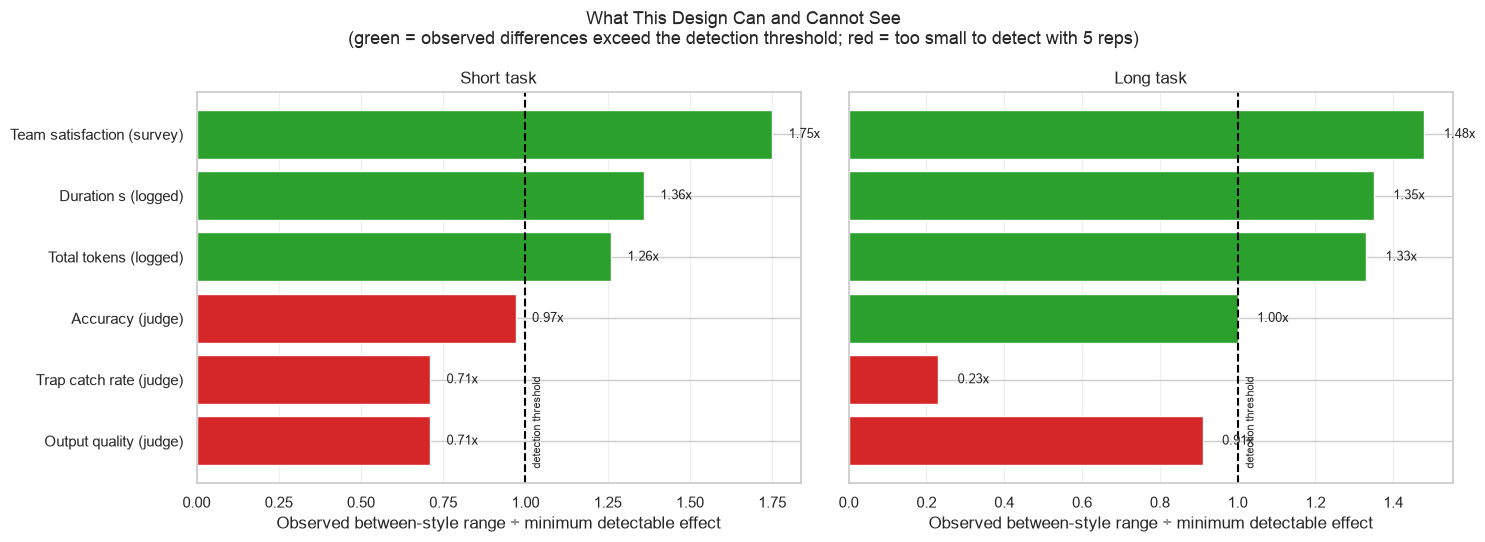


Interpretation:
  * With 5 repetitions the design only reliably detects between-style
    differences of roughly 2-3 within-condition standard deviations.
  * Metrics in RED are not "unaffected by leadership style" — they are
    UNDER-POWERED. The correct claim is "no detectable difference at n=5".
  * Metrics in GREEN are adequately powered, so those effects are robust.
  * To halve the MDE, repetitions would have to roughly quadruple (n≈20 per cell,
    i.e. 280 runs), because the standard error scales with 1/sqrt(n).


In [123]:
# ─────────────────────────────────────────────────────────────────────────────
# Minimum detectable effect (MDE) by simulation, using the noise actually
# observed in the data. Answers: "how big would a true style difference have to
# be for 7 conditions x 5 reps to detect it 80% of the time?"
# ─────────────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(16)

N_PER_CELL = 5
N_STYLES = len(STYLE_ORDER)
N_SIMS = 1500
TARGET_POWER = 0.80
ALPHA = 0.05


def simulated_power(true_range, sd, n_per_cell=N_PER_CELL, n_sims=N_SIMS):
    """Power of a 7-group Kruskal-Wallis test when the true style means are
    evenly spaced over `true_range` and within-condition noise is `sd`."""
    if sd == 0:
        return 1.0
    true_means = np.linspace(0, true_range, N_STYLES)
    hits = 0
    for _ in range(n_sims):
        groups = [rng.normal(m, sd, n_per_cell) for m in true_means]
        try:
            _, p = stats.kruskal(*groups)
        except ValueError:      # all values identical
            continue
        if p < ALPHA:
            hits += 1
    return hits / n_sims


def find_mde(sd, max_multiple=8.0, step=0.1):
    """Smallest true best-worst range (in raw units) reaching TARGET_POWER."""
    multiple = step
    while multiple <= max_multiple:
        if simulated_power(multiple * sd, sd) >= TARGET_POWER:
            return multiple * sd, multiple
        multiple += step
    return np.nan, np.nan


power_metrics = {
    'Output quality (judge)': 'quality_mean',
    'Accuracy (judge)': 'accuracy',
    'Trap catch rate (judge)': 'trap_catch_rate',
    'Team satisfaction (survey)': 'survey_team_mean',
    'Total tokens (logged)': 'total_tokens',
    'Duration s (logged)': 'duration_seconds',
}

power_rows = []
for label, col in power_metrics.items():
    for task in ['short', 'long']:
        sub = df[df['task'] == task]
        # Noise = mean within-condition SD across the 7 styles (5 reps each)
        sd = sub.groupby('style')[col].std().mean()
        style_means = sub.groupby('style')[col].mean()
        observed_range = style_means.max() - style_means.min()
        mde, mde_in_sd = find_mde(sd)
        obs_power = simulated_power(observed_range, sd)
        power_rows.append({
            'Metric': label,
            'Task': task,
            'Within-cond SD': round(sd, 3),
            'Observed range': round(observed_range, 3),
            'MDE (80% power)': round(mde, 3) if not np.isnan(mde) else 'n/a',
            'MDE in SD units': round(mde_in_sd, 2) if not np.isnan(mde_in_sd) else 'n/a',
            'Observed / MDE': round(observed_range / mde, 2) if mde and not np.isnan(mde) else 'n/a',
            'Power at observed range': round(obs_power, 2),
            'Detectable?': 'yes' if (not np.isnan(mde) and observed_range >= mde) else 'no',
        })

df_power = pd.DataFrame(power_rows)

print('=' * 100)
print(f'   MINIMUM DETECTABLE EFFECT — {N_STYLES} styles x {N_PER_CELL} reps, '
      f'Kruskal-Wallis, alpha = {ALPHA}, target power = {TARGET_POWER:.0%}')
print('=' * 100)
print(df_power.to_string(index=False))

# ── Visual: observed spread vs. what the design can see ─────────────────────
# Use ONE shared row order for both panels (sharey=True means the panels must
# agree on the category order, otherwise labels and bars get mismatched).
_short = df_power[df_power['Task'] == 'short'].copy()
_short['ratio'] = pd.to_numeric(_short['Observed / MDE'], errors='coerce')
metric_order = _short.sort_values('ratio')['Metric'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, task in zip(axes, ['short', 'long']):
    sub = df_power[df_power['Task'] == task].copy()
    sub['ratio'] = pd.to_numeric(sub['Observed / MDE'], errors='coerce')
    sub = sub.set_index('Metric').reindex(metric_order).reset_index()
    colors = ['#2ca02c' if r >= 1 else '#d62728' for r in sub['ratio']]
    ax.barh(sub['Metric'], sub['ratio'], color=colors, edgecolor='white')
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5)
    ax.text(1.02, -0.45, 'detection threshold', rotation=90, fontsize=8, va='bottom')
    ax.set_xlabel('Observed between-style range ÷ minimum detectable effect')
    ax.set_title(f'{task.capitalize()} task')
    for y, r in enumerate(sub['ratio']):
        ax.text(r + 0.05, y, f'{r:.2f}x', va='center', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

fig.suptitle('What This Design Can and Cannot See\n'
             '(green = observed differences exceed the detection threshold; '
             'red = too small to detect with 5 reps)', fontsize=13)
fig.tight_layout()
save_fig('03_power_mde')
plt.show()

print('\nInterpretation:')
print(f'  * With {N_PER_CELL} repetitions the design only reliably detects between-style')
print('    differences of roughly 2-3 within-condition standard deviations.')
print('  * Metrics in RED are not "unaffected by leadership style" — they are')
print('    UNDER-POWERED. The correct claim is "no detectable difference at n=5".')
print('  * Metrics in GREEN are adequately powered, so those effects are robust.')
print('  * To halve the MDE, repetitions would have to roughly quadruple (n≈20 per cell,')
print('    i.e. 280 runs), because the standard error scales with 1/sqrt(n).')

## §6 — Quality by Task and Dimension (Deep Dive)

The control agent evaluates four quality dimensions independently. Because leadership style may have different effects on Accuracy, Completeness, Cohesion, and Quality, we split the analysis by task type (short vs. long). Long and short tasks differ in complexity: short tasks require four charts and a 100-word summary, while long tasks require predictive modeling and a 400-word report. Different styles may therefore excel in different dimensions.

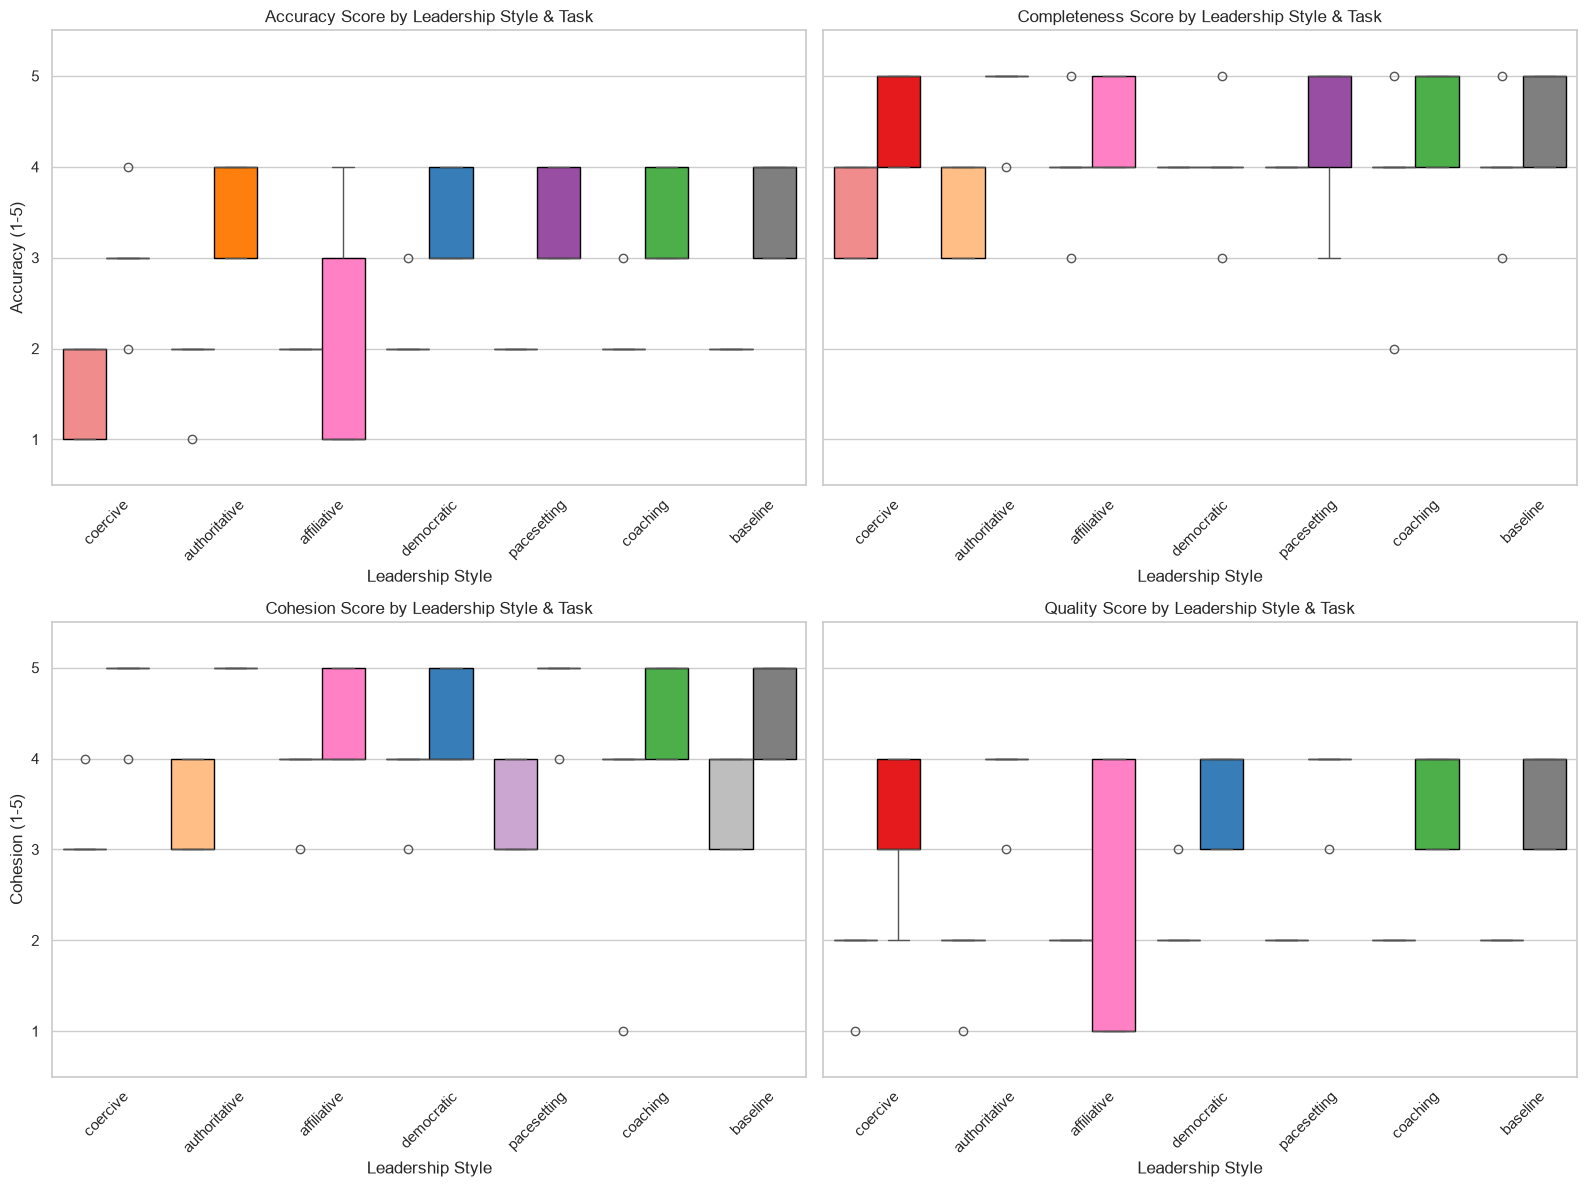

Mean quality dimension scores by task and style:
 task         style  accuracy  completeness  cohesion  quality
 long      coercive       3.0           4.6       4.8      3.2
 long authoritative       3.6           4.8       5.0      3.8
 long   affiliative       2.0           4.4       4.4      2.2
 long    democratic       3.4           4.0       4.4      3.6
 long   pacesetting       3.4           4.4       4.8      3.8
 long      coaching       3.4           4.6       4.6      3.6
 long      baseline       3.6           4.6       4.6      3.6
short      coercive       1.6           3.6       3.2      1.8
short authoritative       1.8           3.6       3.4      1.8
short   affiliative       2.0           4.0       3.8      2.0
short    democratic       2.2           4.0       3.8      2.2
short   pacesetting       2.0           4.0       3.4      2.0
short      coaching       2.2           3.8       3.4      2.0
short      baseline       2.0           4.0       3.6      2.0


In [124]:
dim_cols = ['accuracy', 'completeness', 'cohesion', 'quality']

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()
for i, dim in enumerate(dim_cols):
    ax = axes[i]
    sns.boxplot(data=df, x='style', y=dim, hue='task', order=STYLE_ORDER, ax=ax, legend=False, hue_order=['short', 'long'])
    color_style_task_bars(ax, edgecolor='black')

    ax.set_title(f'{dim.title()} Score by Leadership Style & Task')
    ax.set_ylabel(f'{dim.title()} (1-5)')
    ax.set_xlabel('Leadership Style')
    ax.set_ylim(0.5, 5.5)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig('03_quality_dimensions_by_task')
plt.show()

# Summary table
dim_summary = df.groupby(['task', 'style'])[dim_cols].mean().reset_index().sort_values(['task', 'style'])
print('Mean quality dimension scores by task and style:')
print(dim_summary.round(2).to_string(index=False))

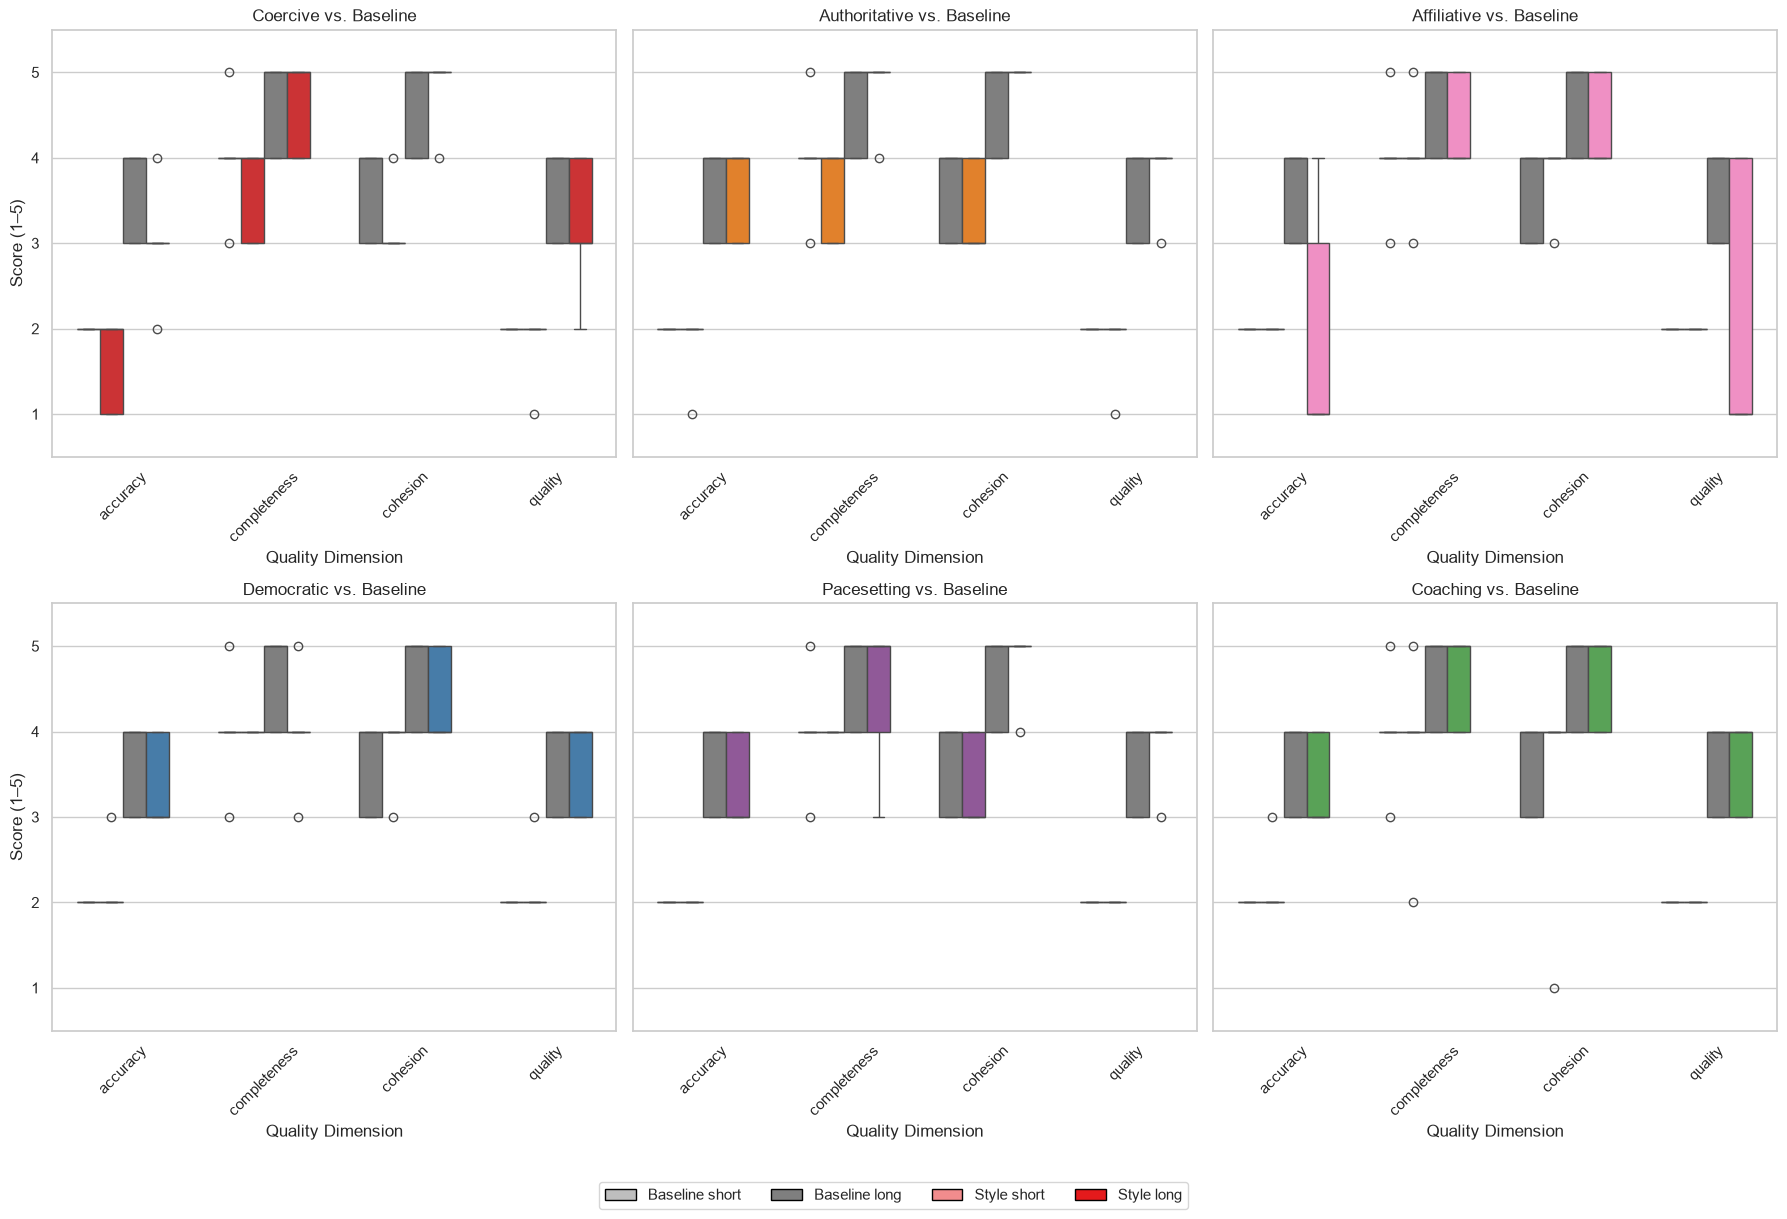

In [125]:
dim_cols = ['accuracy', 'completeness', 'cohesion', 'quality']

# Long-format data for the four quality dimensions
df_melt = df[['style', 'task'] + dim_cols].melt(
    id_vars=['style', 'task'],
    value_vars=dim_cols,
    var_name='dimension',
    value_name='score'
)

# Exclude baseline; one panel per non-baseline leadership style
non_baseline_styles = [s for s in STYLE_ORDER if s != 'baseline']

fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharey=True)
axes = axes.flatten()

for i, style in enumerate(non_baseline_styles):
    ax = axes[i]
    subset = df_melt[df_melt['style'].isin(['baseline', style])].copy()
    subset['condition'] = subset['style'].astype(str) + ' ' + subset['task'].astype(str)

    condition_order = [
        'baseline short',
        f'{style} short',
        'baseline long',
        f'{style} long'
    ]

    palette = {
        'baseline short': to_rgba('#7f7f7f', 0.5),
        f'{style} short': to_rgba(STYLE_COLORS[style], 0.5),
        'baseline long': '#7f7f7f',
        f'{style} long': STYLE_COLORS[style]
    }

    sns.boxplot(
        data=subset,
        x='dimension',
        y='score',
        hue='condition',
        order=dim_cols,
        hue_order=condition_order,
        palette=palette,
        width=0.65,
        dodge=True,
        ax=ax,
        legend=False
    )

    ax.set_title(f'{style.title()} vs. Baseline')
    ax.set_ylabel('Score (1–5)')
    ax.set_xlabel('Quality Dimension')
    ax.set_ylim(0.5, 5.5)
    ax.tick_params(axis='x', rotation=45)

# One shared legend on the figure
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=to_rgba('#7f7f7f', 0.5), edgecolor='black', label='Baseline short'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#7f7f7f', edgecolor='black', label='Baseline long'),
    plt.Rectangle((0, 0), 1, 1, facecolor=to_rgba(STYLE_COLORS[non_baseline_styles[0]], 0.5), edgecolor='black', label='Style short'),
    plt.Rectangle((0, 0), 1, 1, facecolor=STYLE_COLORS[non_baseline_styles[0]], edgecolor='black', label='Style long')
]
fig.legend(handles=handles, title='', loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 1])
save_fig('03_quality_dimensions_by_style')
plt.show()


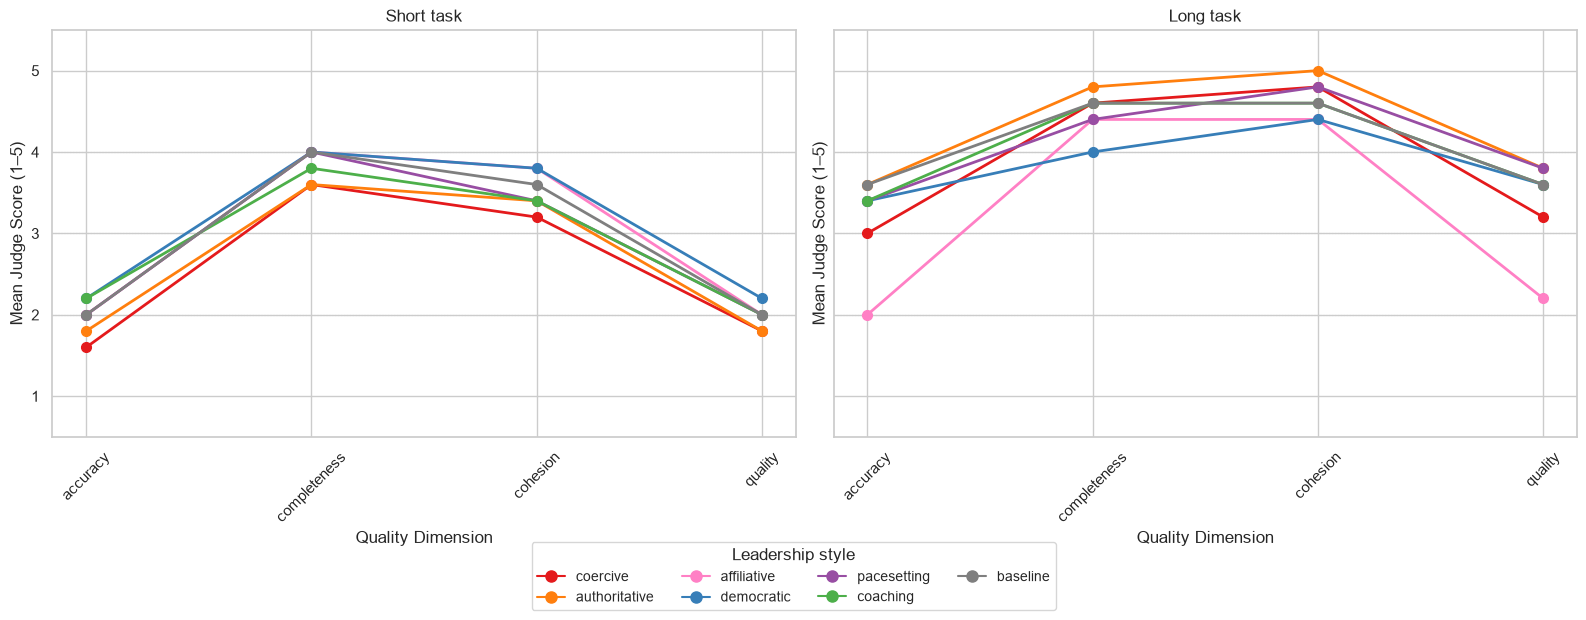

In [126]:
dim_cols = ['accuracy', 'completeness', 'cohesion', 'quality']

# Long-format quality dimensions for the line chart
df_dim = (df[['style', 'task'] + dim_cols]
          .melt(id_vars=['style', 'task'],
                value_vars=dim_cols,
                var_name='dimension',
                value_name='score'))

# Mean judge score per style, task and dimension
df_dim_mean = (df_dim
               .groupby(['style', 'task', 'dimension'], observed=True)['score']
               .mean()
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

style_handles = []
for style in STYLE_ORDER:
    color = STYLE_COLORS[style]
    style_handles.append(Line2D([0], [0], color=color, marker='o', markersize=8, label=style))
    for ax, task in zip(axes, ['short', 'long']):
        task_data = df_dim_mean[
            (df_dim_mean['style'].astype(str) == style) & (df_dim_mean['task'].astype(str) == task)
        ].set_index('dimension').reindex(dim_cols)
        ax.plot(
            dim_cols,
            task_data['score'],
            color=color,
            marker='o',
            markersize=7,
            linewidth=2,
            label=style
        )

for ax, task in zip(axes, ['short', 'long']):
    ax.set_title(f'{task.title()} task')
    ax.set_ylim(0.5, 5.5)
    ax.set_ylabel('Mean Judge Score (1–5)')
    ax.set_xlabel('Quality Dimension')
    ax.tick_params(axis='x', rotation=45)
    for y in [2, 3, 4]:
        ax.axhline(y, color='lightgray', linestyle=':', linewidth=0.8, zorder=0)

# One shared style legend below the two subplots
fig.legend(handles=style_handles, title='Leadership style', loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
save_fig('03_quality_dimension_lines')
plt.show()


## §7 — Per-Trap Catch Rates

Data quality traps are task-specific. For the short task, the traps are the 79.3°C outlier, country name duplicates, and city name duplicates. For the long task, the traps are trivial features, sentinel values, the 79.3°C outlier, and duplicate unit features. This section shows which styles are most effective at catching each trap, using the control agent's judgment.

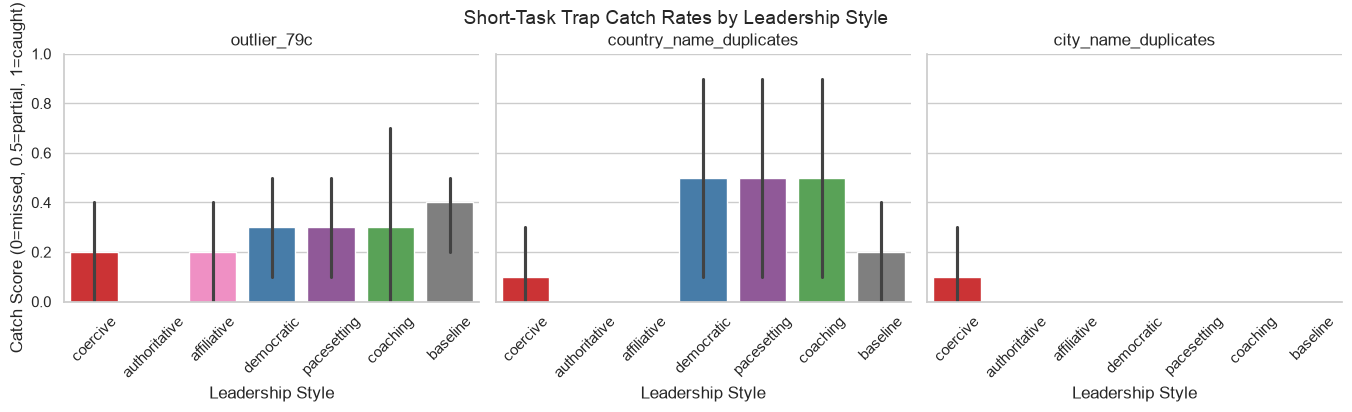

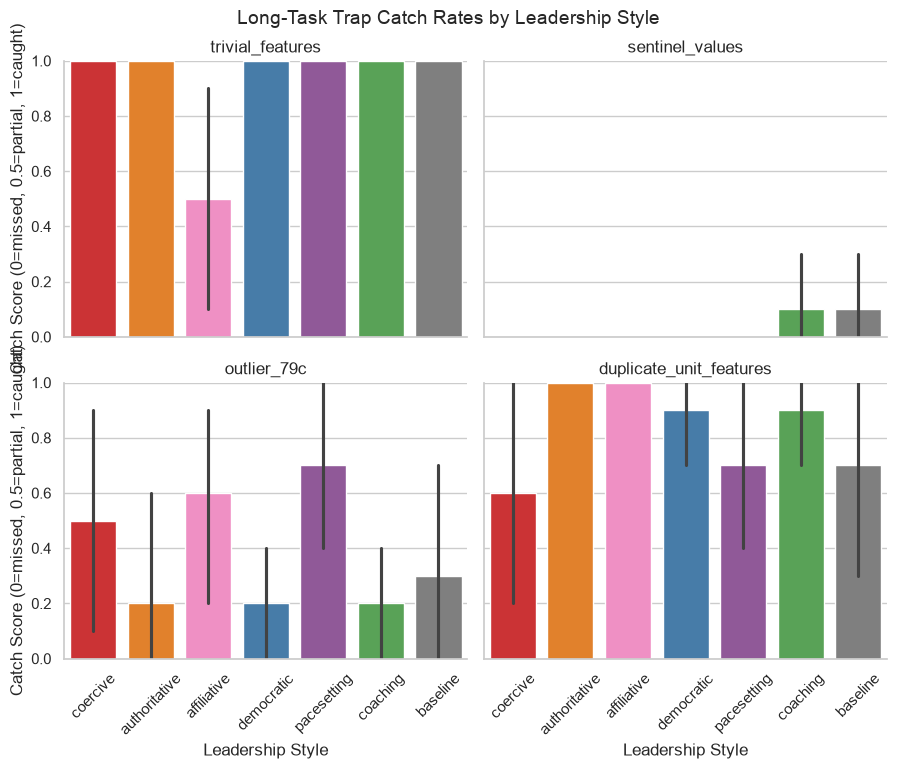

 task                    trap         style  score
 long duplicate_unit_features   affiliative    1.0
 long duplicate_unit_features authoritative    1.0
 long duplicate_unit_features      baseline    0.7
 long duplicate_unit_features      coaching    0.9
 long duplicate_unit_features      coercive    0.6
 long duplicate_unit_features    democratic    0.9
 long duplicate_unit_features   pacesetting    0.7
 long             outlier_79c   affiliative    0.6
 long             outlier_79c authoritative    0.2
 long             outlier_79c      baseline    0.3
 long             outlier_79c      coaching    0.2
 long             outlier_79c      coercive    0.5
 long             outlier_79c    democratic    0.2
 long             outlier_79c   pacesetting    0.7
 long         sentinel_values   affiliative    0.0
 long         sentinel_values authoritative    0.0
 long         sentinel_values      baseline    0.1
 long         sentinel_values      coaching    0.1
 long         sentinel_values  

In [127]:
trap_rows = []
for d in run_dirs:
    evp = os.path.join(d, 'evaluation.json')
    if not os.path.exists(evp):
        continue
    with open(evp, 'r', encoding='utf-8') as f:
        ev = json.load(f)
    traps = ev.get('traps', {})
    folder = os.path.basename(d)
    parts = folder.split('_')
    for trap_id, info in traps.items():
        status = info.get('status', 'missed')
        score = {'caught': 1.0, 'partial': 0.5, 'missed': 0.0}.get(status, 0.0)
        trap_rows.append({'run': folder, 'style': parts[0], 'task': parts[1],
                          'trap': trap_id, 'status': status, 'score': score})

df_traps = pd.DataFrame(trap_rows)

# Short task traps
short_traps = ['outlier_79c', 'country_name_duplicates', 'city_name_duplicates']
df_traps_short = df_traps[(df_traps['task'] == 'short') & (df_traps['trap'].isin(short_traps))]

g_short = sns.catplot(data=df_traps_short, x='style', y='score', hue='style',
                      col='trap', kind='bar', order=STYLE_ORDER,
                      hue_order=STYLE_ORDER, palette=STYLE_COLORS,
                      col_order=short_traps, col_wrap=3,
                      height=3.5, aspect=1.3, legend=False)
for ax in g_short.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
g_short.set_axis_labels('Leadership Style', 'Catch Score (0=missed, 0.5=partial, 1=caught)')
g_short.set_titles('{col_name}')
g_short.fig.suptitle('Short-Task Trap Catch Rates by Leadership Style', y=1.02)
save_fig('03_trap_catch_short_task')
plt.show()

# Long task traps
long_traps = ['trivial_features', 'sentinel_values', 'outlier_79c', 'duplicate_unit_features']
df_traps_long = df_traps[(df_traps['task'] == 'long') & (df_traps['trap'].isin(long_traps))]

g_long = sns.catplot(data=df_traps_long, x='style', y='score', hue='style',
                     col='trap', kind='bar', order=STYLE_ORDER,
                     hue_order=STYLE_ORDER, palette=STYLE_COLORS,
                     col_order=long_traps, col_wrap=2,
                     height=3.5, aspect=1.3, legend=False)
for ax in g_long.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
g_long.set_axis_labels('Leadership Style', 'Catch Score (0=missed, 0.5=partial, 1=caught)')
g_long.set_titles('{col_name}')
g_long.fig.suptitle('Long-Task Trap Catch Rates by Leadership Style', y=1.02)
save_fig('03_trap_catch_long_task')
plt.show()

trap_summary = (df_traps.groupby(['task', 'trap', 'style'])['score']
                         .mean().reset_index().sort_values(['task', 'trap', 'style']))
print(trap_summary.round(2).to_string(index=False))

### §7a — Trap-Catch Matrix: Caught / Partial / Missed Percentages

The trap-by-style mean score is useful, but a concrete count of how many runs ended up caught, partially handled, or missed is often more convincing. The plots below show the percentage of runs (N = 5 per style for each task–trap combination) in each status. The stacked-bar grid gives one panel per trap; the heatmaps compress the same information into caught % and missed % matrices.

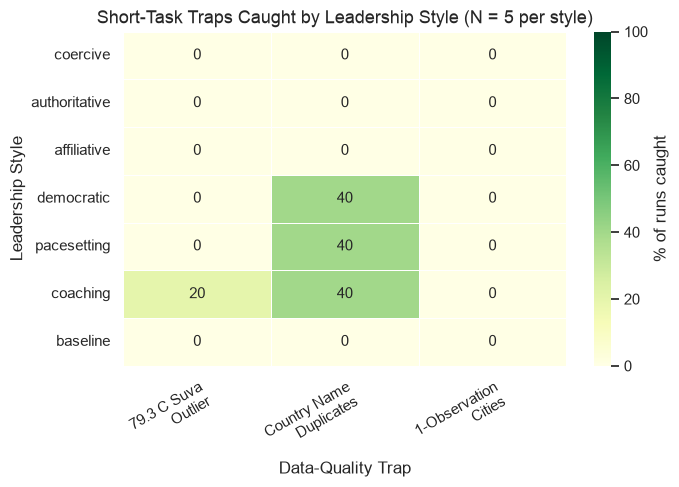

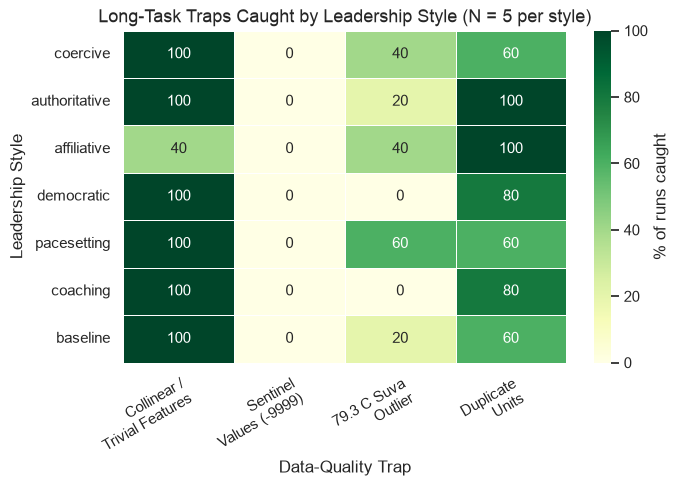


% of runs in which each trap was CAUGHT:

Short task:
trap           79.3 C Suva\nOutlier  Country Name\nDuplicates  1-Observation\nCities
style                                                                               
coercive                          0                         0                      0
authoritative                     0                         0                      0
affiliative                       0                         0                      0
democratic                        0                        40                      0
pacesetting                       0                        40                      0
coaching                         20                        40                      0
baseline                          0                         0                      0

Long task:
trap           Collinear /\nTrivial Features  Sentinel\nValues (-9999)  79.3 C Suva\nOutlier  Duplicate\nUnits
style                                                    

In [128]:
# Data-quality trap status split by TASK, TRAP, and LEADERSHIP STYLE.
# Short and long tasks check completely different traps (see src/evaluation/control_agent.py),
# so each task gets its own saved figure -- no overall means across task types or traps.

TRAP_LABELS = {
    'outlier_79c': '79.3 C Suva\nOutlier',
    'country_name_duplicates': 'Country Name\nDuplicates',
    'city_name_duplicates': '1-Observation\nCities',
    'trivial_features': 'Collinear /\nTrivial Features',
    'sentinel_values': 'Sentinel\nValues (-9999)',
    'duplicate_unit_features': 'Duplicate\nUnits',
}

SHORT_TRAPS = ['outlier_79c', 'country_name_duplicates', 'city_name_duplicates']
LONG_TRAPS = ['trivial_features', 'sentinel_values', 'outlier_79c', 'duplicate_unit_features']
TRAP_LABELS_SHORT = {t: TRAP_LABELS[t] for t in SHORT_TRAPS}
TRAP_LABELS_LONG = {t: TRAP_LABELS[t] for t in LONG_TRAPS}

def _plot_task_heatmap(task, trap_list, col_labels, title):
    """Plot % of runs in which each trap was CAUGHT, by leadership style."""
    sub = df_traps[(df_traps['task'] == task) & (df_traps['trap'].isin(trap_list))]
    caught = (
        sub.assign(caught=(sub['status'] == 'caught').astype(float))
        .pivot_table(index='style', columns='trap', values='caught', aggfunc='mean')
        .reindex(index=STYLE_ORDER, columns=trap_list, fill_value=0)
        * 100
    )
    caught = caught.rename(columns=col_labels)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        caught,
        annot=True,
        fmt='.0f',
        cmap='YlGn',
        vmin=0,
        vmax=100,
        linewidths=0.5,
        cbar_kws={'label': '% of runs caught'},
        ax=ax,
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Data-Quality Trap')
    ax.set_ylabel('Leadership Style')
    ax.set_yticklabels(STYLE_ORDER, rotation=0)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
    plt.tight_layout()
    return fig, caught

# Short task heatmap
fig, caught_short = _plot_task_heatmap(
    'short', SHORT_TRAPS, TRAP_LABELS_SHORT,
    'Short-Task Traps Caught by Leadership Style (N = 5 per style)'
)
save_fig('03_trap_matrix_short')
plt.show()

# Long task heatmap
fig, caught_long = _plot_task_heatmap(
    'long', LONG_TRAPS, TRAP_LABELS_LONG,
    'Long-Task Traps Caught by Leadership Style (N = 5 per style)'
)
save_fig('03_trap_matrix_long')
plt.show()

# Print the underlying % caught tables
print('\n% of runs in which each trap was CAUGHT:')
print('\nShort task:')
print(caught_short.round(0).astype(int).to_string())
print('\nLong task:')
print(caught_long.round(0).astype(int).to_string())

### §7b — Trap Survival Matrix (Catch Rate by Trap & Task)

Heatmaps of the **mean catch score** per leadership style and per data-quality trap, split by **task complexity** (short vs. long).

- **0.0** = missed, **0.5** = partial, **1.0** = caught.
- Only the traps that actually occur for each task are shown, so the two matrices have different columns.
- This lets you see whether a style consistently survives all traps, or only specific kinds of methodological flaws.


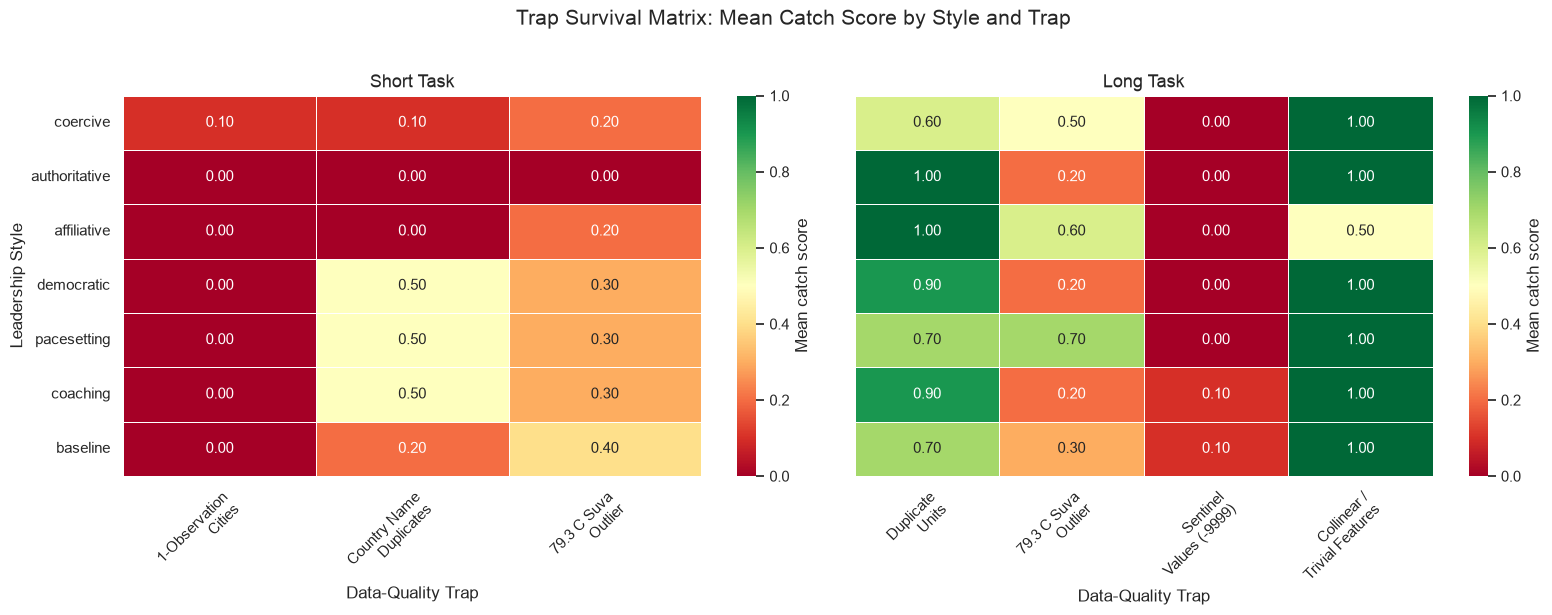

In [129]:
# Mean catch score by style, trap and task (short vs. long)
matrix_short = (df_traps[df_traps['task'] == 'short']
                .groupby(['style', 'trap'])['score']
                .mean()
                .unstack(fill_value=0.0)
                .reindex(index=STYLE_ORDER)
                .rename(columns=TRAP_LABELS))

matrix_long = (df_traps[df_traps['task'] == 'long']
               .groupby(['style', 'trap'])['score']
               .mean()
               .unstack(fill_value=0.0)
               .reindex(index=STYLE_ORDER)
               .rename(columns=TRAP_LABELS))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, task, mat in zip(axes, ['Short Task', 'Long Task'], [matrix_short, matrix_long]):
    sns.heatmap(
        mat,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        vmin=0.0,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={'label': 'Mean catch score'},
        ax=ax
    )
    ax.set_title(task, fontsize=13)
    ax.set_xlabel('Data-Quality Trap')
    ax.set_ylabel('Leadership Style')
    # Rotate x labels for readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Only show y label on left plot
axes[1].set_ylabel('')

fig.suptitle('Trap Survival Matrix: Mean Catch Score by Style and Trap', fontsize=15, y=1.02)
plt.tight_layout()
save_fig('03_trap_survival')
plt.show()

## §7c — Judge Reliability Diagnostics (Is a Second Judge Needed?)

All output-quality results in this notebook rest on a **single LLM-as-judge pass** (`control_agent.py`, one call per run, no second rater, no human-coded subsample). Because output quality is the *primary* dependent variable and it produced a **null result** across leadership styles, we have to ask whether the null is a property of the *teams* or a property of the *measuring instrument*.

The four diagnostics below quantify that risk. None of them can prove the judge is reliable or unreliable — that requires a second rater — but they show how much of the observed variance the instrument could plausibly be responsible for, and therefore how urgent a second scoring pass is.

| Panel | Diagnostic | Warning sign |
|---|---|---|
| A | Inter-dimension correlation (task-adjusted) | Accuracy ≈ Quality (ρ > 0.9) would mean 4 labels measuring ~1 construct |
| B | Scale-point usage per dimension | Unused scale points mean lower effective resolution, which compresses between-style differences |
| C | Signal-to-noise (η², variance explained by style, within task) | Judge η² far below the logged/survey metrics means the quality DV is noise-dominated |
| D | Judge Accuracy vs. deterministic trap catch rate | No relationship would mean the judge is scoring something other than correctness |

### What the diagnostics actually show

**Reassuring:**
- **A** — the four dimensions are *not* redundant (Accuracy–Quality ρ = 0.67; Cohesion–Accuracy ρ = 0.20). The rubric measures more than one thing.
- **D** — the subjective Accuracy score is significantly anchored to the near-objective trap verdicts (short ρ = +0.48, p = .004; long ρ = +0.63, p = .0001). The judge is scoring correctness, not vibes.

**Concerning:**
- **B** — the judge **never awards a 5** on Accuracy or Quality (top observed = 4) and never awards a 1 or 2 on Completeness. Each dimension uses only 4 of 5 scale points, and the *usable* range is narrower still. Any true between-style difference is measured on a compressed ruler.
- **C** — style explains only **η² ≈ 0.16–0.19** of within-task variance for judge Quality/Accuracy, and 0.01–0.02 for Completeness/Cohesion, against **η² = 0.54** for the survey and **0.40–0.43** for logged tokens/duration. The quality DV carries roughly a third of the signal that the other DVs carry.
- **D (noise floor)** — the mean within-condition SD is **0.40 quality points** across 5 runs of an *identical* prompt. On the short task the entire between-style spread is 0.50 points, i.e. only **1.2× that noise floor** — indistinguishable. On the long task the spread is 1.05 points (2.6× the noise floor), yet Kruskal-Wallis is still non-significant because the per-condition SDs are uneven.

### Recommendation for the supervisor conversation

The instrument looks **valid but coarse and noisy**, not broken. The case for a second judge is therefore *moderate and targeted*, not existential:

1. The judge is anchored to ground truth (D) and multidimensional (A) — so the rubric design is defensible as is.
2. But with one rating per run we cannot decompose the 0.40-point within-condition SD into *judge disagreement* vs. *genuine run-to-run variation in team behaviour*. That distinction is exactly what determines whether the quality null is meaningful.
3. **Cheapest resolution:** re-score a ~20-run stratified subsample with a second independent pass, and report Spearman/Krippendorff agreement plus the mean absolute score difference. If self-disagreement is ≈ 0.4 points, the short-task null is uninformative and must be reported as such. If it is ≈ 0.1 points, then the 0.40-point noise is real team variance and the null becomes a genuine substantive finding.

Either outcome is publishable — the point is that right now we cannot tell which one we have.


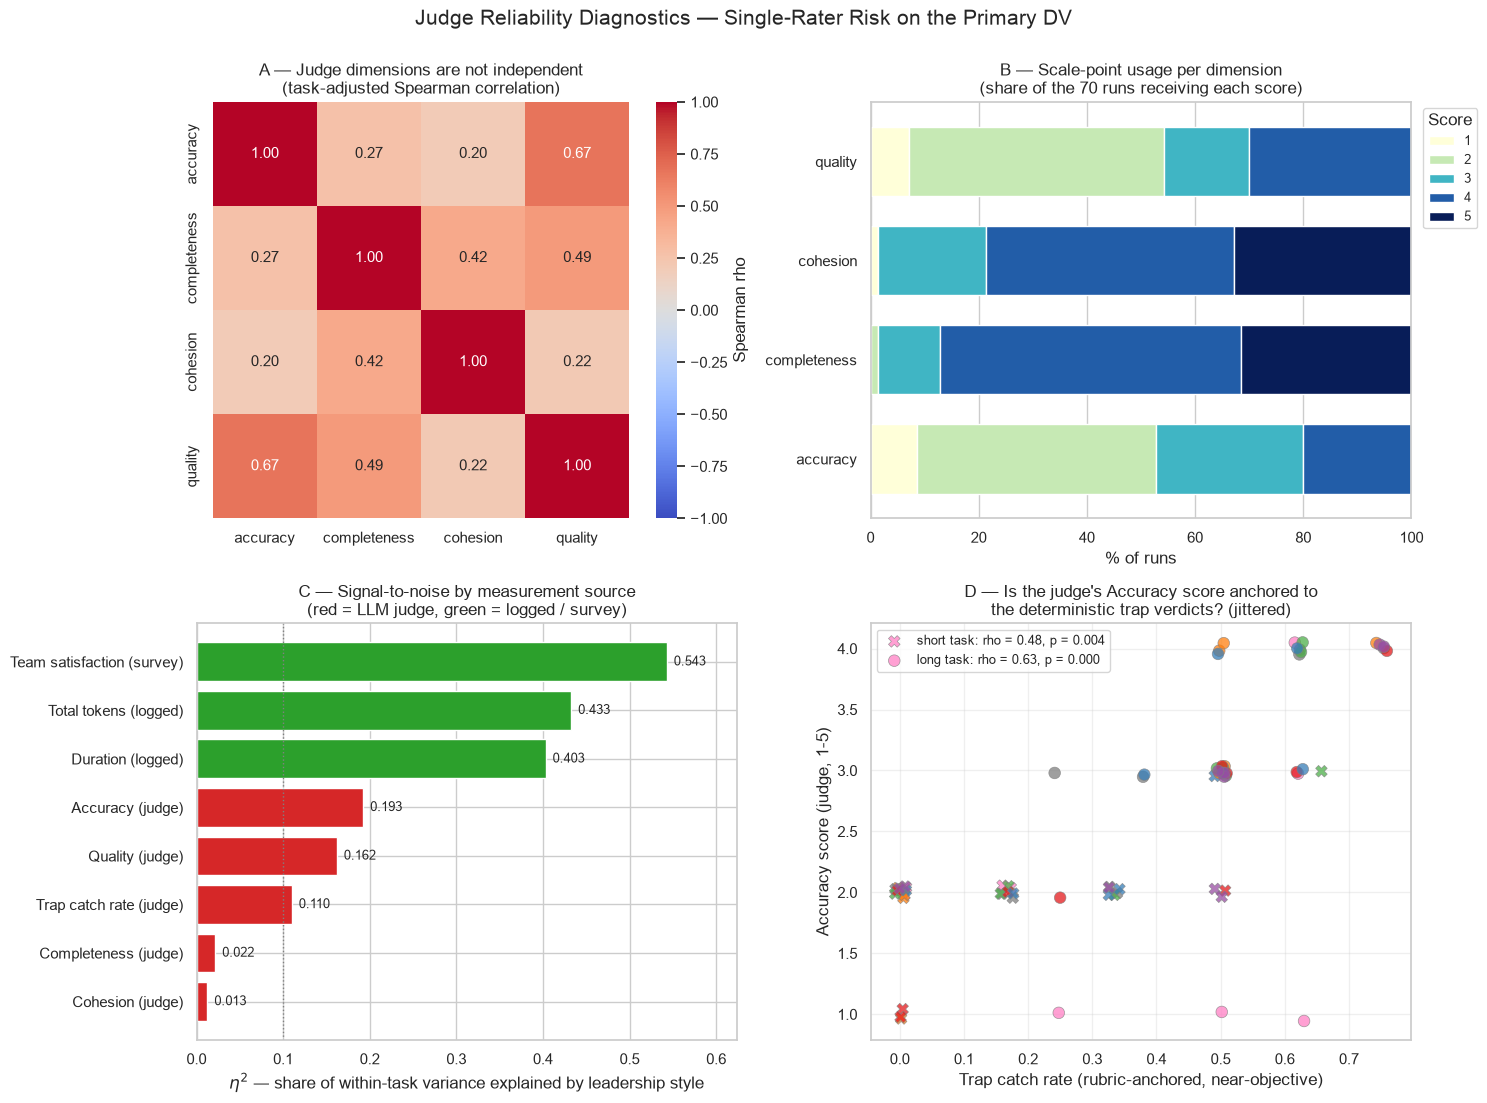

   JUDGE RELIABILITY EVIDENCE

A. Task-adjusted correlation between judge dimensions (Spearman):
              accuracy  completeness  cohesion  quality
accuracy          1.00          0.27      0.20     0.67
completeness      0.27          1.00      0.42     0.49
cohesion          0.20          0.42      1.00     0.22
quality           0.67          0.49      0.22     1.00

   -> accuracy vs quality: rho = 0.67  (partially distinct)

B. Scale-point usage (% of 70 runs):
   accuracy  completeness  cohesion  quality
1       8.6           0.0       1.4      7.1
2      44.3           1.4       0.0     47.1
3      27.1          11.4      20.0     15.7
4      20.0          55.7      45.7     30.0
5       0.0          31.4      32.9      0.0

   Distinct score values actually used per dimension:
     accuracy     : 4 of 5 points [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
     completeness : 4 of 5 points [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
     cohesion     : 4 of 

In [130]:
# ─────────────────────────────────────────────────────────────────────────────
# Judge reliability diagnostics: how much of the quality signal could be
# instrument noise rather than a real leadership-style effect?
# ─────────────────────────────────────────────────────────────────────────────
JUDGE_DIMS = ['accuracy', 'completeness', 'cohesion', 'quality']


def _task_adjusted(series):
    """Remove the (large) task main effect so we look at within-task variation."""
    return series.astype(float) - series.astype(float).groupby(df['task']).transform('mean')


def eta_squared_style(col):
    """Share of within-task variance in `col` explained by leadership style."""
    resid = _task_adjusted(df[col])
    grand = resid.mean()
    ss_total = ((resid - grand) ** 2).sum()
    if ss_total == 0:
        return np.nan
    group_means = resid.groupby(df['style'], observed=False).transform('mean')
    ss_between = ((group_means - grand) ** 2).sum()
    return ss_between / ss_total


fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ── Panel A: inter-dimension correlation (task-adjusted) ─────────────────────
adj = pd.DataFrame({d: _task_adjusted(df[d]) for d in JUDGE_DIMS})
dim_corr = adj.corr(method='spearman')
sns.heatmap(dim_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, cbar_kws={'label': "Spearman rho"}, ax=axes[0, 0])
axes[0, 0].set_title('A — Judge dimensions are not independent\n(task-adjusted Spearman correlation)')

# ── Panel B: how much of the 1-5 scale does the judge actually use? ──────────
usage = (pd.DataFrame({d: df[d].value_counts() for d in JUDGE_DIMS})
           .reindex([1, 2, 3, 4, 5])
           .fillna(0))
usage_pct = usage / usage.sum() * 100
usage_pct.T.plot(kind='barh', stacked=True, ax=axes[0, 1],
                 colormap='YlGnBu', edgecolor='white', width=0.7)
axes[0, 1].set_title('B — Scale-point usage per dimension\n(share of the 70 runs receiving each score)')
axes[0, 1].set_xlabel('% of runs')
axes[0, 1].set_ylabel('')
axes[0, 1].legend(title='Score', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# ── Panel C: variance explained by style, judge metrics vs. non-judge metrics ─
snr_metrics = {
    'Accuracy (judge)': 'accuracy',
    'Completeness (judge)': 'completeness',
    'Cohesion (judge)': 'cohesion',
    'Quality (judge)': 'quality',
    'Trap catch rate (judge)': 'trap_catch_rate',
    'Team satisfaction (survey)': 'survey_team_mean',
    'Total tokens (logged)': 'total_tokens',
    'Duration (logged)': 'duration_seconds',
}
snr = (pd.Series({label: eta_squared_style(col) for label, col in snr_metrics.items()})
         .sort_values())
bar_colors = ['#d62728' if 'judge' in lab else '#2ca02c' for lab in snr.index]
axes[1, 0].barh(snr.index, snr.values, color=bar_colors, edgecolor='white')
axes[1, 0].axvline(0.10, color='gray', linestyle=':', linewidth=1)
axes[1, 0].set_xlim(0, max(0.6, float(snr.max()) * 1.15))
axes[1, 0].set_xlabel(r'$\eta^2$ — share of within-task variance explained by leadership style')
axes[1, 0].set_title('C — Signal-to-noise by measurement source\n(red = LLM judge, green = logged / survey)')
for y, v in enumerate(snr.values):
    axes[1, 0].text(v + 0.008, y, f'{v:.3f}', va='center', fontsize=9)

# ── Panel D: subjective Accuracy vs. near-objective trap catch rate ──────────
for task, marker in [('short', 'X'), ('long', 'o')]:
    sub = df[df['task'] == task]
    rho, p = stats.spearmanr(sub['trap_catch_rate'], sub['accuracy'])
    axes[1, 1].scatter(sub['trap_catch_rate'] + np.random.uniform(-0.01, 0.01, len(sub)),
                       sub['accuracy'] + np.random.uniform(-0.06, 0.06, len(sub)),
                       s=70, marker=marker, alpha=0.75,
                       c=[STYLE_COLORS[s] for s in sub['style']],
                       edgecolors='gray', linewidth=0.5,
                       label=f'{task} task: rho = {rho:.2f}, p = {p:.3f}')
axes[1, 1].set_xlabel('Trap catch rate (rubric-anchored, near-objective)')
axes[1, 1].set_ylabel('Accuracy score (judge, 1-5)')
axes[1, 1].set_title('D — Is the judge\'s Accuracy score anchored to\nthe deterministic trap verdicts? (jittered)')
axes[1, 1].legend(loc='upper left', fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Judge Reliability Diagnostics — Single-Rater Risk on the Primary DV', fontsize=15, y=1.0)
fig.tight_layout()
save_fig('03_judge_diagnostics')
plt.show()

# ── Printed evidence for the second-judge decision ──────────────────────────
print('=' * 78)
print('   JUDGE RELIABILITY EVIDENCE')
print('=' * 78)

print('\nA. Task-adjusted correlation between judge dimensions (Spearman):')
print(dim_corr.round(2).to_string())
acc_qual = dim_corr.loc['accuracy', 'quality']
print(f'\n   -> accuracy vs quality: rho = {acc_qual:.2f}'
      f"  ({'redundant, effectively one construct' if abs(acc_qual) > 0.9 else 'partially distinct'})")

print('\nB. Scale-point usage (% of 70 runs):')
print(usage_pct.round(1).to_string())
print('\n   Distinct score values actually used per dimension:')
for d in JUDGE_DIMS:
    vals = sorted(df[d].unique())
    print(f'     {d:13s}: {len(vals)} of 5 points {vals}')

print('\nC. Variance explained by leadership style, within task (eta^2):')
for label, val in snr.sort_values(ascending=False).items():
    print(f'     {label:28s} {val:.3f}')

# Noise floor: how big is run-to-run scatter inside a single condition,
# compared with the entire spread between style means?
within_sd = df.groupby(['style', 'task'], observed=False)['quality_mean'].std().mean()
between_spread = (df.groupby(['style', 'task'], observed=False)['quality_mean'].mean()
                    .groupby(level='task').agg(lambda s: s.max() - s.min()))
print('\nD. Noise floor on the primary DV (quality_mean):')
print(f'     Mean within-condition SD (5 reps, identical prompt): {within_sd:.3f}')
for task_name, spread in between_spread.items():
    ratio = spread / within_sd if within_sd else np.nan
    print(f'     {task_name:5s} task: spread between style means = {spread:.3f} '
          f'({ratio:.2f}x the within-condition SD)')

print('\n   Judge Accuracy vs. trap catch rate (per task):')
for task in ['short', 'long']:
    sub = df[df['task'] == task]
    rho, p = stats.spearmanr(sub['trap_catch_rate'], sub['accuracy'])
    print(f'     {task:5s}: rho = {rho:+.2f}, p = {p:.4f}')

print('\n' + '-' * 78)
print('READ-OUT')
print('-' * 78)
print('Reassuring: the judge is multidimensional (Panel A: accuracy~quality rho well below')
print('1.0) and its Accuracy score is significantly anchored to the near-objective trap')
print('verdicts (Panel D). The rubric itself is defensible as designed.')
print()
print('Concerning: the judge never uses the full 1-5 range (Panel B), and leadership style')
print('explains roughly a third as much variance in the judge scores as it does in the')
print('survey and logged metrics (Panel C). On the SHORT task the entire between-style')
print('spread is only ~1.2x the within-condition SD, i.e. inside the noise.')
print()
print('Consequence: with ONE rating per run the within-condition SD cannot be split into')
print('judge disagreement vs. genuine run-to-run team variation. Until that split is')
print('measured, the short-task quality null is UNVERIFIED rather than established. A')
print('second scoring pass on a ~20-run stratified subsample would settle it.')
print('-' * 78)

### §7c.1 — Why a Second Judge Would Strengthen This Thesis (detailed reasoning)

> **Status: open question — to be discussed with the supervisor before any re-scoring is done.** This cell documents the full argument so the decision can be made with the evidence in view. Nothing here has been acted on yet.

The four panels above are the evidence. This section explains, step by step, what they imply and why a second scoring pass is the natural next move.

---

#### 1. The problem in one sentence

Output quality is the **primary dependent variable** of this thesis, it produced a **null result**, and it was measured **exactly once per run by a single LLM judge**. A null result on a single-rater measurement cannot distinguish between *"leadership style does not affect quality"* and *"my ruler is too blunt to see the difference"*. Every other conclusion in the thesis rests on measurements that either are deterministic (tokens, duration, turn counts — logged, not judged) or have an independent second source (the survey). Quality is the one DV with no such backstop.

#### 2. What "one rating per run" actually costs us

Across the 5 repetitions of a *single* condition — same style prompt, same task, same model — the judge's quality scores vary with a **standard deviation of 0.402 points** (Panel D). That number is a mixture of two completely different things:

| Source of the 0.402 | What it would mean | Implication for the thesis |
|---|---|---|
| **Genuine run-to-run variation** — the team really did produce better work in run 3 than in run 1 (LLM stochasticity, different code paths, different revision decisions) | The measurement is fine; agent teams are just noisy | The quality null is a **real substantive finding**: style does not overcome run-level randomness |
| **Judge disagreement** — the deliverables were comparable, but the judge scored them differently | The measurement is unreliable | The quality null is **uninformative**: we never had the resolution to detect a style effect |

**With one rating per run these two are mathematically inseparable.** There is no statistic that can decompose them from the current data — it requires a second measurement of the *same* deliverable. This is the whole argument in a nutshell.

#### 3. Why this matters *specifically* here, and not just as generic good practice

It matters because of how the noise compares to the effect we are trying to detect (Panel D and §5a):

- **Short task:** the full spread between the best and worst style mean is **0.50 points**, against a within-condition SD of **0.402**. The signal is **1.24×** the noise. That is inside the measurement error — even a modest amount of judge inconsistency would completely swamp it.
- **Long task:** the spread is **1.05 points**, i.e. **2.61×** the noise floor. Better, but Kruskal-Wallis is still non-significant (p = .44) because the per-condition SDs are very uneven (affiliative alone has SD ≈ 1.03 on quality and 1.41 on accuracy).

So the null is not sitting comfortably far from the detection threshold — it is sitting *right on it* (§5a: observed/MDE = 0.71 short, 0.91 long). When a result is that close to the resolution limit, the reliability of the instrument stops being a footnote and becomes the deciding factor.

#### 4. Corroborating signals from the other panels

- **Panel C (signal-to-noise).** Leadership style explains η² ≈ **0.16–0.19** of within-task variance in the judge's Quality and Accuracy scores, and only **0.01–0.02** for Completeness and Cohesion. The same styles, measured by the survey, give **η² = 0.54**, and by logged tokens/duration, **η² = 0.40–0.43**. The judge-based DV carries roughly *a third* of the signal that every other DV carries. Something is absorbing that variance — either the teams genuinely converge on similar quality, or the judge is adding noise. Again: indistinguishable with one rating.
- **Panel B (scale compression).** The judge **never awards a 5** on Accuracy or Quality (maximum observed = 4) and never a 1 or 2 on Completeness. Each dimension uses 4 of 5 points, and the *effective* range is narrower still — Accuracy puts 44% of all runs on the single value "2". A coarse ruler mechanically shrinks between-group differences and inflates the apparent tie between styles. A second pass would show whether the judge lands on the same coarse value consistently, or whether that "2" is a soft judgement that could just as easily have been a 1 or a 3.

#### 5. What speaks *against* panic (this is not a broken instrument)

Two panels give real reassurance, and the thesis should say so explicitly rather than over-apologising:

- **Panel A (construct validity).** The four dimensions are **not** redundant: Accuracy–Quality ρ = 0.67, Cohesion–Accuracy ρ = 0.20, Completeness–Cohesion ρ = 0.42. If the judge were producing one undifferentiated "goodness" score with four labels, these would all be > 0.9. They are not. The rubric genuinely measures multiple things.
- **Panel D (criterion validity).** The judge's *subjective* Accuracy score is significantly correlated with the *near-objective, rubric-anchored* trap verdicts: short ρ = **+0.48** (p = .004), long ρ = **+0.63** (p = .0001). The judge is tracking actual correctness against ground truth, not scoring on style or fluency.

So the honest characterisation is: **valid but coarse and noisy** — not wrong, just low-resolution. That is exactly the situation where a reliability estimate is cheap and decisive, rather than a situation demanding that the whole evaluation be redone.

#### 6. Concretely proposed procedure (if the supervisor agrees)

1. **Sample:** ~20 runs, stratified — both tasks, all 7 styles represented, and deliberately include runs from the extremes (highest and lowest quality_mean) plus several from the middle.
2. **Re-score:** run `control_agent.py` again on those runs, unchanged rubric, unchanged inputs. Two variants are possible, and they answer different questions:
   - *same model, independent second pass* → measures **intra-rater** reliability (how much of the 0.402 is the judge disagreeing with itself)
   - *different model as judge* → measures **inter-rater** reliability (how much is idiosyncratic to this particular model)
   The first is the cheaper and more directly relevant test for the null; the second is the stronger methodological claim.
3. **Report:** Spearman ρ and Krippendorff's α between passes, plus the **mean absolute difference** in score points and the % exact agreement per dimension.
4. **Decision rule, set in advance:**
   - Mean absolute difference **≈ 0.4 points** (i.e. as large as the entire within-condition SD) → the judge is the dominant noise source. The short-task quality null must be reported as *uninformative*, and the long-task null heavily caveated.
   - Mean absolute difference **≈ 0.1 points** → judge noise is small, the 0.402 SD is genuine team variation, and the quality null becomes a **defensible substantive finding**: leadership style does not overcome run-level randomness in output quality.

#### 7. Why this is worth doing even though it is extra work

Both outcomes improve the thesis, which is the mark of a test worth running:

- If reliability is **good**, the null result gets substantially stronger. Instead of "I found no difference", the claim becomes "I found no difference, *and* I demonstrated my instrument was reliable enough to have found one" — which is a far more publishable negative result.
- If reliability is **poor**, that is itself a finding worth reporting: it documents a concrete methodological limitation of LLM-as-judge evaluation in multi-agent research, which is currently a widespread and largely unvalidated practice in the literature.

The cost is roughly 20 additional API calls and one analysis cell. The alternative is defending a null result on the primary DV with no reliability evidence at all, which is the most likely single point of attack in the defence.

#### 8. If we decide *not* to re-score

That is a legitimate choice given the time budget. In that case the thesis must:

- report the within-condition SD of 0.402 explicitly alongside every quality result,
- state plainly that single-rater LLM-as-judge scoring without a reliability estimate is a limitation,
- restrict the claim to *"no detectable difference at n = 5 with a single-rater instrument"*, and
- list the reliability check as concrete future work in §8.3.

Written that way the null is still honest and defensible — it is simply weaker than it needs to be.


## §8 — Integrated Summary and Takeaways

This table brings together the **three main DVs** (Output Quality, Efficiency, Worker Satisfaction) by style and task. Validity and manipulation checks are reported in `02_validation_check.ipynb`; sentiment analysis is reported in `03_sentiment_analysis.ipynb`.


In [131]:
main_summary = (df.groupby(['style', 'task'])
                   .agg(quality_mean=('quality_mean', 'mean'),
                        trap_catch_rate=('trap_catch_rate', 'mean'),
                        total_tokens=('total_tokens', 'mean'),
                        total_input_tokens=('total_input_tokens', 'mean'),
                        total_output_tokens=('total_output_tokens', 'mean'),
                        total_api_calls=('total_api_calls', 'mean'),
                        total_code_executions=('total_code_executions', 'mean'),
                        duration_seconds=('duration_seconds', 'mean'),
                        revision_rounds=('revision_rounds', 'mean'),
                        survey_team_mean=('survey_team_mean', 'mean'))
                   .reset_index()
                   .sort_values(['style', 'task']))
print('Summary of the three main result dimensions by style and task:')
print(main_summary.round(2).to_string(index=False))


Summary of the three main result dimensions by style and task:
        style  task  quality_mean  trap_catch_rate  total_tokens  total_input_tokens  total_output_tokens  total_api_calls  total_code_executions  duration_seconds  revision_rounds  survey_team_mean
     coercive  long          3.90             0.52      187680.2            164517.8              23162.4             19.4                    2.6            254.31              0.4              4.17
     coercive short          2.55             0.13      131833.2            118571.2              13262.0             20.0                    2.0            152.72              1.0              4.10
authoritative  long          4.30             0.55      217174.8            191573.4              25601.4             19.4                    2.6            299.29              0.6              4.77
authoritative short          2.65             0.00      153633.0            138777.0              14856.0             19.4                   

## Communication Effort Allocation by Phase

This plot shows how communication effort (measured by message token counts) is distributed across the workflow phases for each leadership style.

Phases are grouped into:
- **Briefing** (Phase 1)
- **Planning** (Phase 2)
- **Execution** (Phases 3–4: Coding + Writing)
- **Review** (Phase 5)
- **Revision** (Phase 6)

The bars are stacked to 100% so you can directly compare the relative effort allocation across styles.


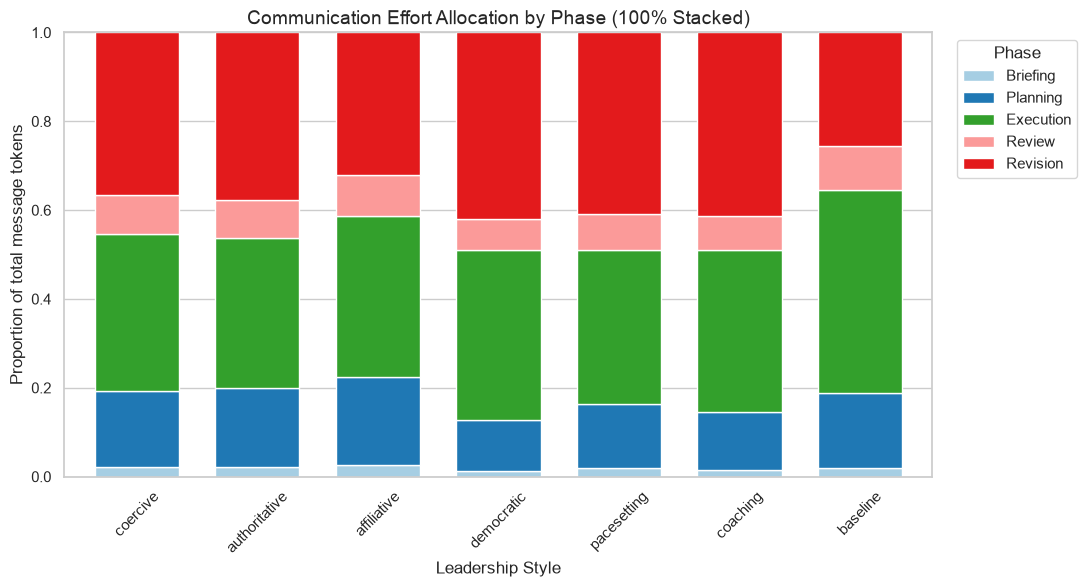

Token share by style and phase group:
phase_group    Briefing  Planning  Execution  Review  Revision
style                                                         
coercive            2.2      17.1       35.4     8.7      36.6
authoritative       2.2      17.9       33.6     8.6      37.8
affiliative         2.6      19.8       36.3     9.1      32.2
democratic          1.2      11.4       38.3     7.0      42.0
pacesetting         1.9      14.5       34.7     8.0      40.9
coaching            1.6      13.0       36.4     7.6      41.4
baseline            1.9      16.9       45.9     9.9      25.5


In [132]:
# Load per-message token counts and phases from messages.jsonl
comm_rows = []
for d in run_dirs:
    msg_file = os.path.join(d, 'messages.jsonl')
    if not os.path.exists(msg_file):
        continue
    folder = os.path.basename(d)
    parts = folder.split('_')
    with open(msg_file, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            try:
                msg = json.loads(line)
            except json.JSONDecodeError:
                continue
            # Skip system markers; focus on actual agent communication
            if msg.get('sender') == 'system':
                continue
            phase = msg.get('phase')
            if phase is None:
                continue
            phase_group = {
                1: 'Briefing',
                2: 'Planning',
                3: 'Execution',
                4: 'Execution',
                5: 'Review',
                6: 'Revision'
            }.get(int(phase), 'Other')
            comm_rows.append({
                'run': folder,
                'style': parts[0],
                'task': parts[1],
                'phase_group': phase_group,
                'tokens': msg.get('token_count', 0)
            })

df_comm = pd.DataFrame(comm_rows)

# Compute share of tokens per phase-group within each style
comm_pivot = (df_comm.groupby(['style', 'phase_group'])['tokens']
                     .sum()
                     .unstack(fill_value=0))
comm_pivot = comm_pivot.reindex(STYLE_ORDER)
comm_pivot = comm_pivot[['Briefing', 'Planning', 'Execution', 'Review', 'Revision']]
comm_share = comm_pivot.div(comm_pivot.sum(axis=1), axis=0)

# 100% stacked bar plot
colors = ['#a6cee3', '#1f78b4', '#33a02c', '#fb9a99', '#e31a1c']
ax = comm_share.plot(kind='bar', stacked=True, color=colors, figsize=(11, 6), width=0.7, edgecolor='white')
ax.set_title('Communication Effort Allocation by Phase (100% Stacked)', fontsize=14)
ax.set_ylabel('Proportion of total message tokens')
ax.set_xlabel('Leadership Style')
ax.set_ylim(0, 1)
ax.legend(title='Phase', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig('03_phase_effort')
plt.show()

print('Token share by style and phase group:')
print((comm_share * 100).round(1).to_string())

### Absolute Token Usage Across Original Phases

This line chart shows the **raw token usage** per workflow phase for each leadership-style and task combination.

- **x-axis:** Original phases 1–6 (1 Briefing, 2 Planning, 3 Coding, 4 Writing, 5 Review, 6 Revision).
- **y-axis:** Total message tokens per run.
- **14 lines:** 7 leadership styles × 2 tasks.
- **Short runs:** 50% transparent with **X** markers.
- **Long runs:** Opaque with **dot** markers.
- **Shaded area:** 90% confidence interval across the 5 runs per condition.


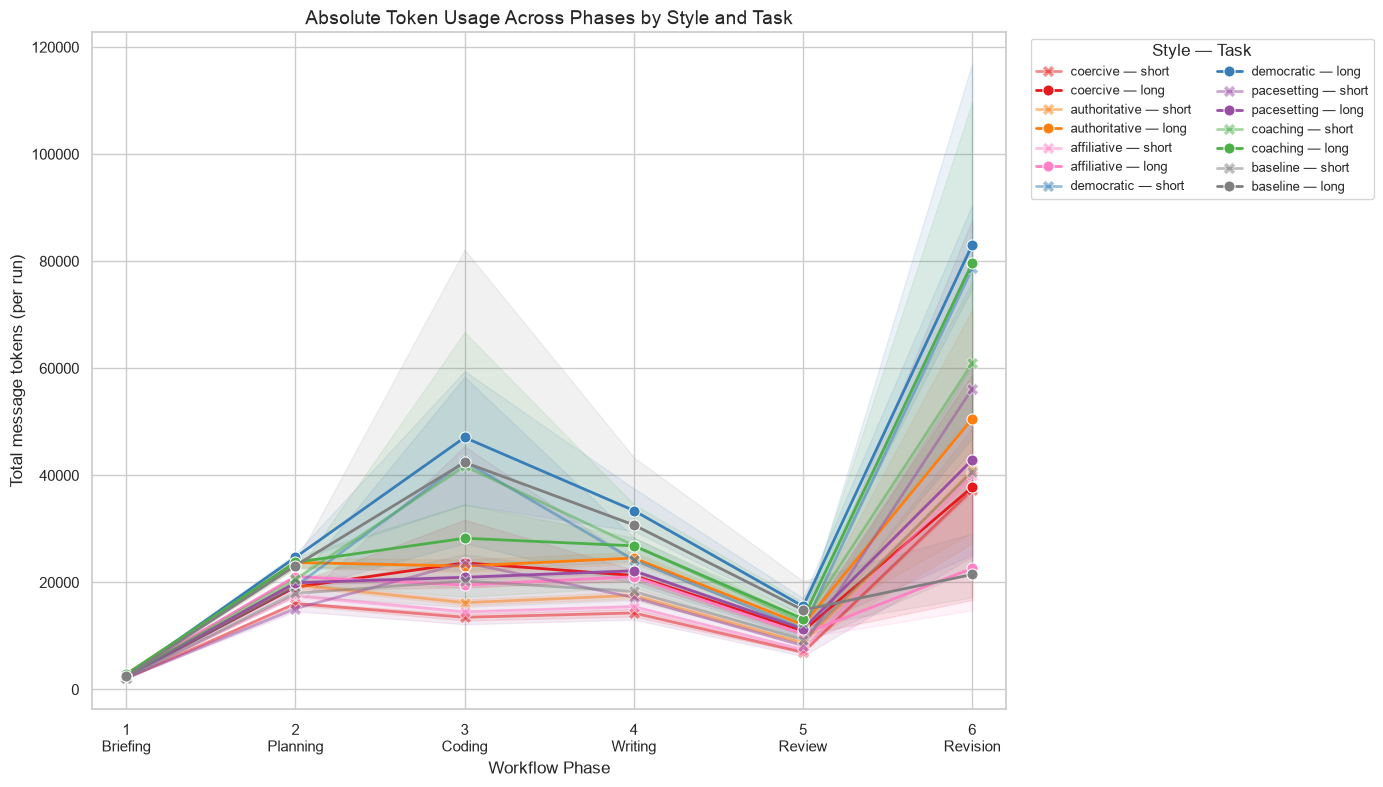

In [133]:
# Re-load messages but keep the original 6 phases (not grouped)
phase_rows = []
for d in run_dirs:
    msg_file = os.path.join(d, 'messages.jsonl')
    if not os.path.exists(msg_file):
        continue
    folder = os.path.basename(d)
    parts = folder.split('_')
    with open(msg_file, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            try:
                msg = json.loads(line)
            except json.JSONDecodeError:
                continue
            if msg.get('sender') == 'system':
                continue
            phase = msg.get('phase')
            if phase is None:
                continue
            phase_rows.append({
                'run': folder,
                'style': parts[0],
                'task': parts[1],
                'phase': int(phase),
                'tokens': msg.get('token_count', 0)
            })

df_phase_tokens = pd.DataFrame(phase_rows)

# Sum tokens per run / style / task / phase
df_phase_run = (df_phase_tokens.groupby(['run', 'style', 'task', 'phase'])['tokens']
                               .sum()
                               .reset_index())

# Plot one line per (style, task) combination
fig, ax = plt.subplots(figsize=(14, 8))

for style in STYLE_ORDER:
    for task in ['short', 'long']:
        alpha = 0.5 if task == 'short' else 1.0
        marker = 'X' if task == 'short' else 'o'
        color = STYLE_COLORS[style]
        subset = df_phase_run[(df_phase_run['style'] == style) & (df_phase_run['task'] == task)]
        if subset.empty:
            continue
        sns.lineplot(
            data=subset,
            x='phase',
            y='tokens',
            color=color,
            alpha=alpha,
            marker=marker,
            markersize=8,
            linewidth=2,
            errorbar=('ci', 90),
            err_kws={'alpha': 0.10},
            label=f'{style} — {task}',
            ax=ax
        )

ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xticklabels(['1\nBriefing', '2\nPlanning', '3\nCoding', '4\nWriting', '5\nReview', '6\nRevision'])
ax.set_xlabel('Workflow Phase')
ax.set_ylabel('Total message tokens (per run)')
ax.set_title('Absolute Token Usage Across Phases by Style and Task', fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Style — Task', ncol=2, fontsize=9)
ax.set_xlim(0.8, 6.2)
plt.tight_layout()
save_fig('03_phase_tokens_absolute')
plt.show()

### Absolute Token Usage Across Phases — Style vs. Baseline

Six side-by-side subplots. Each panel compares one leadership style (colored) against the **Baseline** (gray), using the same short/long marker and transparency scheme as the main line plot.


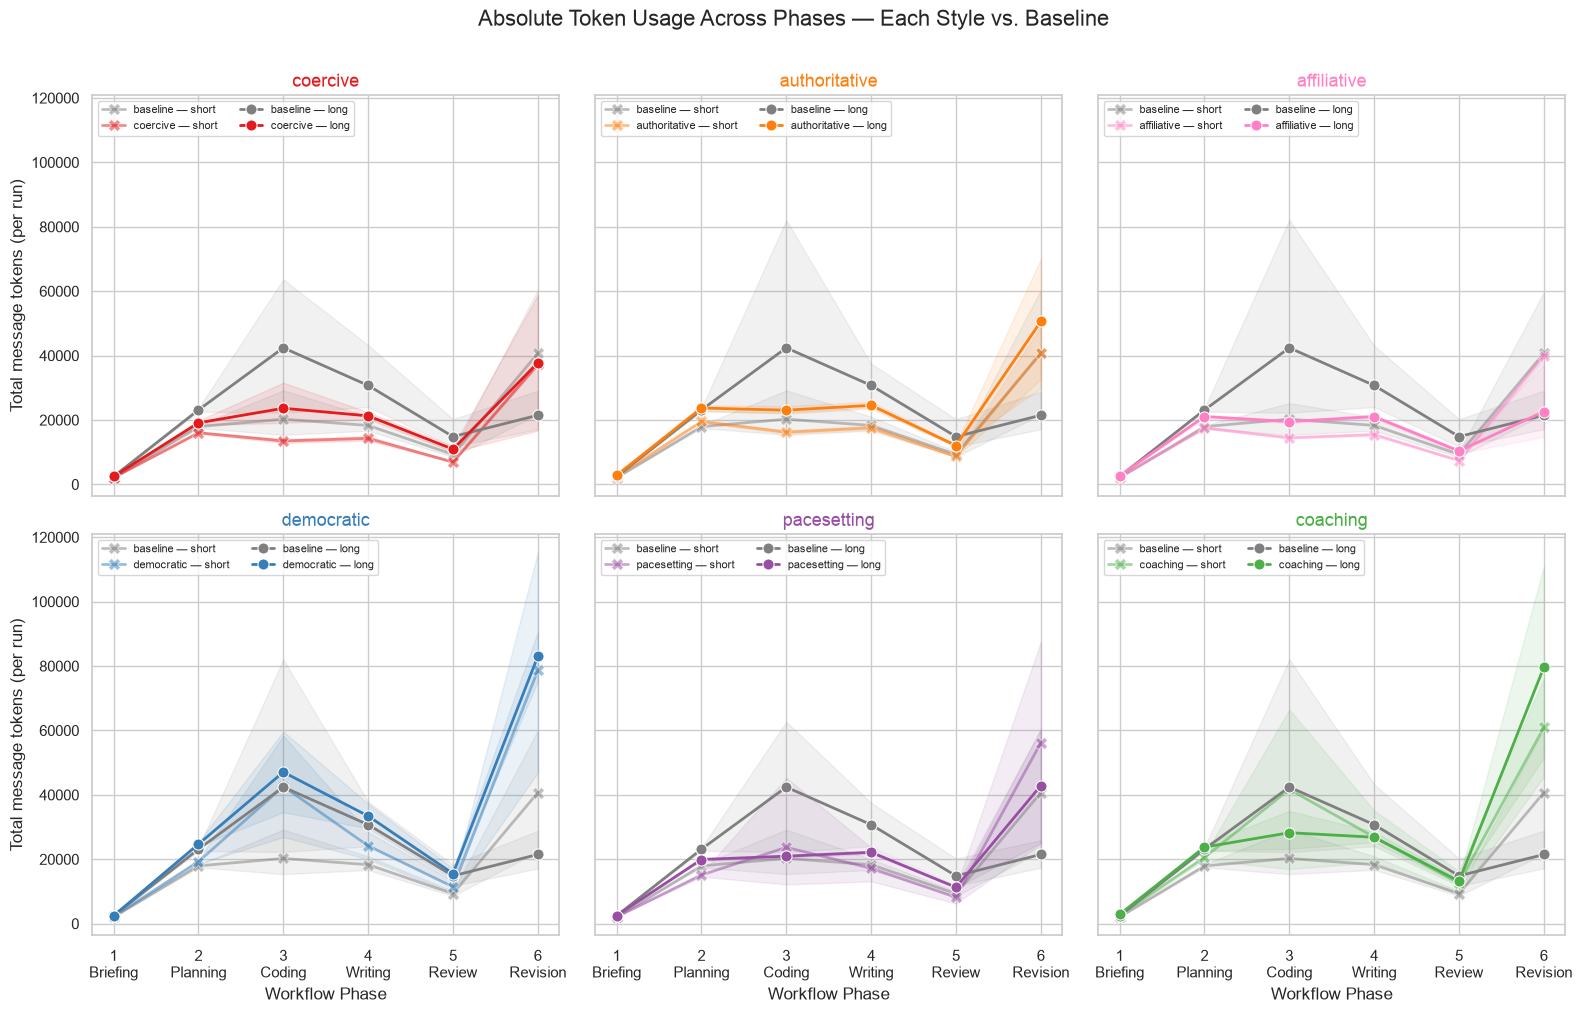

In [134]:
# Uses df_phase_run from the previous cell
# 6 subplots: one per non-baseline style
non_baseline = [s for s in STYLE_ORDER if s != 'baseline']

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, focal_style in enumerate(non_baseline):
    ax = axes[idx]
    for task in ['short', 'long']:
        alpha = 0.5 if task == 'short' else 1.0
        marker = 'X' if task == 'short' else 'o'
        
        # Baseline line
        base_subset = df_phase_run[(df_phase_run['style'] == 'baseline') & (df_phase_run['task'] == task)]
        if not base_subset.empty:
            sns.lineplot(
                data=base_subset,
                x='phase',
                y='tokens',
                color=STYLE_COLORS['baseline'],
                alpha=alpha,
                marker=marker,
                markersize=8,
                linewidth=2,
                errorbar=('ci', 90),
                err_kws={'alpha': 0.10},
                label=f'baseline — {task}',
                ax=ax
            )
        
        # Focal style line
        focal_subset = df_phase_run[(df_phase_run['style'] == focal_style) & (df_phase_run['task'] == task)]
        if not focal_subset.empty:
            sns.lineplot(
                data=focal_subset,
                x='phase',
                y='tokens',
                color=STYLE_COLORS[focal_style],
                alpha=alpha,
                marker=marker,
                markersize=8,
                linewidth=2,
                errorbar=('ci', 90),
                err_kws={'alpha': 0.10},
                label=f'{focal_style} — {task}',
                ax=ax
            )
    
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(['1\nBriefing', '2\nPlanning', '3\nCoding', '4\nWriting', '5\nReview', '6\nRevision'])
    ax.set_xlabel('Workflow Phase')
    ax.set_title(focal_style, color=STYLE_COLORS[focal_style], fontsize=13)
    ax.legend(loc='upper left', fontsize=8, ncol=2)

axes[0].set_ylabel('Total message tokens (per run)')
axes[3].set_ylabel('Total message tokens (per run)')
fig.suptitle('Absolute Token Usage Across Phases — Each Style vs. Baseline', fontsize=16, y=1.01)
plt.tight_layout()
save_fig('03_phase_tokens_vs_baseline')
plt.show()

## Export run-level data to Excel

For supervisors and thesis readers, the complete run-level dataframe is also exported as an `.xlsx` file.

In [135]:
# Export the run-level dataframe to the notebooks directory using openpyxl
xlsx_path = os.path.abspath('MAS_results.xlsx')
df.to_excel(xlsx_path, index=False, engine='openpyxl')
print(f'Exported {len(df)} runs to {xlsx_path}')
print('Columns:', list(df.columns))


Exported 70 runs to /Users/hellligkeit/Documents/FS/Masterthesis/MAS/notebooks/MAS_results.xlsx
Columns: ['folder', 'style', 'task', 'run_id', 'total_tokens', 'total_input_tokens', 'total_output_tokens', 'total_api_calls', 'total_code_executions', 'total_messages', 'duration_seconds', 'revision_rounds', 'quality_mean', 'overall_quality', 'trap_catch_rate', 'accuracy', 'completeness', 'cohesion', 'quality', 'survey_team_mean', 'survey_coder', 'survey_writer', 'survey_reviewer', 'trap_sentinel_values', 'trap_outlier_79c', 'trap_trivial_features', 'trap_duplicate_unit_features', 'trap_country_name_duplicates', 'trap_city_name_duplicates']
